# Spam / Ham Email Dataset — Exploratory Data Analysis (EDA)

This notebook performs a full EDA pipeline covering:
1. Dataset Overview & Basic Statistics
2. Missing Values & Duplicate Detection
3. Class Distribution Analysis
4. Text Length Distribution
5. Text Cleaning & Preprocessing (with spaCy)
6. Word Frequency Analysis & Word Clouds
7. Feature Extraction (BoW / TF-IDF, Unigram vs Bigram)
8. Train/Test Split
9. Critical Analysis & Model Recommendations

---
---
# Part 1 — Exploratory Data Analysis

## Cell 1 — Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import re
import string
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split

# ── spaCy (optional but recommended) ─────────────────────────────────────────
# Install: pip install spacy && python -m spacy download en_core_web_sm
try:
    import spacy
    nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # keep only tagger
    SPACY_AVAILABLE = True
    print(f"spaCy {spacy.__version__} loaded — lemmatisation enabled.")
except Exception:
    SPACY_AVAILABLE = False
    print("spaCy not found — falling back to simple whitespace tokenisation.")

# ── WordCloud (optional) ──────────────────────────────────────────────────────
try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print("wordcloud not installed — bar charts will be used instead.")

# Plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
print("Libraries loaded.")

spaCy 3.8.11 loaded — lemmatisation enabled.
Libraries loaded.


---
## Section 1 — Dataset Overview

In [2]:
# ── Load dataset ──────────────────────────────────────────────────────────────
df = pd.read_csv("spam_ham_dataset.csv")  # adjust path if needed

# Drop the unnamed index column if present
if "Unnamed: 0" in df.columns:
    df = df.drop(columns=["Unnamed: 0"])

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:")
print(df.dtypes)
print("\nFirst 3 rows:")
df.head(3)

Shape: (5171, 3)

Columns: ['label', 'text', 'label_num']

Data types:
label        object
text         object
label_num     int64
dtype: object

First 3 rows:


,label,text,label_num
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,0
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",0
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",0


In [3]:
# ── Sample messages ───────────────────────────────────────────────────────────
for label in ["ham", "spam"]:
    sample = df[df["label"] == label]["text"].iloc[0]
    print(f"─── {label.upper()} EXAMPLE (first 400 chars) ───")
    print(sample[:400])
    print()

─── HAM EXAMPLE (first 400 chars) ───
Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .

─── SPAM EXAMPLE (first 400 chars) ───
Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
railroad affluent pornographic cuvier
irvin parkhouse blameworthy chlorophyll
robed diagrammatic fogarty clears bayda
inconveniencing managing represented smartness hashish
academies shareholders unload badness
danielson pure caffein
spaniard char



---
## Section 2 — Data Quality: Missing Values & Duplicates

In [4]:
# ── Missing values ────────────────────────────────────────────────────────────
print("Missing values per column:")
print(df.isnull().sum())

# ── Duplicates ────────────────────────────────────────────────────────────────
n_dup = df.duplicated(subset="text").sum()
print(f"\nDuplicate rows (by 'text'): {n_dup}")

if n_dup > 0:
    df = df.drop_duplicates(subset="text").reset_index(drop=True)
    print(f"Duplicates removed. New shape: {df.shape}")
else:
    print("No duplicates — no action needed.")

Missing values per column:
label        0
text         0
label_num    0
dtype: int64

Duplicate rows (by 'text'): 178
Duplicates removed. New shape: (4993, 3)


---
## Section 3 — Class Distribution

       Count  Percentage (%)
label                       
ham     3531            70.7
spam    1462            29.3

Imbalance ratio (ham:spam) = 2.42:1


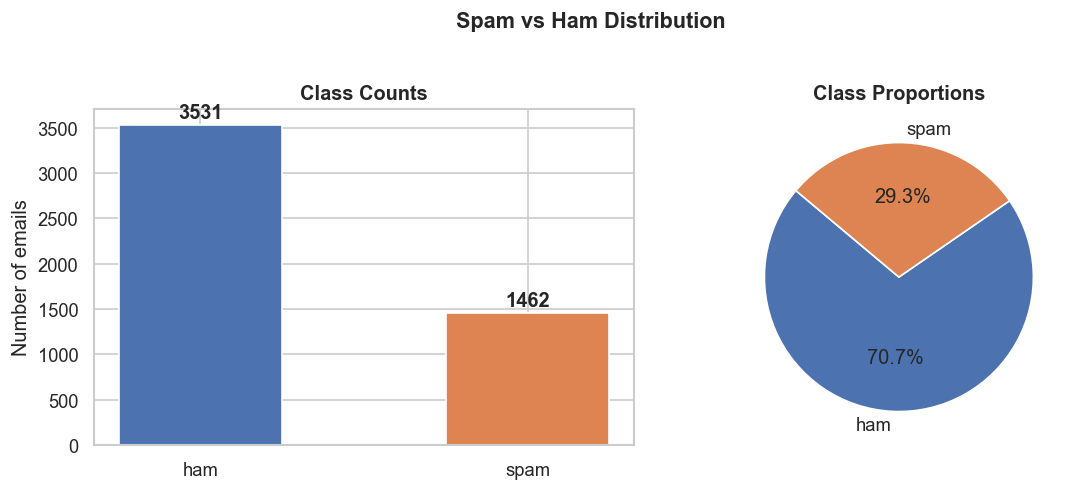

Saved: fig1_class_distribution.png


In [5]:
counts = df["label"].value_counts()
proportions = df["label"].value_counts(normalize=True) * 100

dist_df = pd.DataFrame({"Count": counts, "Percentage (%)": proportions.round(1)})
print(dist_df)
print(f"\nImbalance ratio (ham:spam) = {counts['ham'] / counts['spam']:.2f}:1")

# ── Figure: Bar + Pie ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Bar
bars = axes[0].bar(counts.index, counts.values,
                   color=["#4C72B0", "#DD8452"], edgecolor="white", width=0.5)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 30,
                 str(val), ha="center", va="bottom", fontweight="bold")
axes[0].set_title("Class Counts", fontweight="bold")
axes[0].set_ylabel("Number of emails")

# Pie
axes[1].pie(counts.values, labels=counts.index, autopct="%1.1f%%",
            colors=["#4C72B0", "#DD8452"], startangle=140,
            wedgeprops={"edgecolor": "white"})
axes[1].set_title("Class Proportions", fontweight="bold")

plt.suptitle("Spam vs Ham Distribution", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("fig1_class_distribution.png", bbox_inches="tight")
plt.show()
print("Saved: fig1_class_distribution.png")

> **Observation:** The dataset is moderately imbalanced (~71 % ham, ~29 % spam).  
> This means accuracy alone is misleading as a metric; **F1-score, Precision, Recall, and ROC-AUC** should be used.  
> During training, `class_weight='balanced'` or stratified sampling can compensate.

---
## Section 4 — Text Length Distribution

In [6]:
# Compute length features
df["char_len"]  = df["text"].str.len()
df["word_count"] = df["text"].str.split().str.len()

print("─── Character length stats ───")
print(df.groupby("label")["char_len"].describe().round(1))

print("\n─── Word count stats ───")
print(df.groupby("label")["word_count"].describe().round(1))

─── Character length stats ───
        count    mean     std   min    25%    50%     75%      max
label                                                             
ham    3531.0   994.9  1402.8  18.0  241.0  538.0  1253.5  32258.0
spam   1462.0  1249.3  1840.1  11.0  304.2  589.0  1305.0  22073.0

─── Word count stats ───
        count   mean    std  min   25%    50%    75%     max
label                                                       
ham    3531.0  229.5  337.0  2.0  52.0  127.0  297.5  8862.0
spam   1462.0  239.0  348.0  1.0  58.0  118.0  250.8  3962.0


C:\Users\song wen\AppData\Local\Temp\ipykernel_39188\656542589.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label", y="char_len",
C:\Users\song wen\AppData\Local\Temp\ipykernel_39188\656542589.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_plot, x="label", y="word_count",


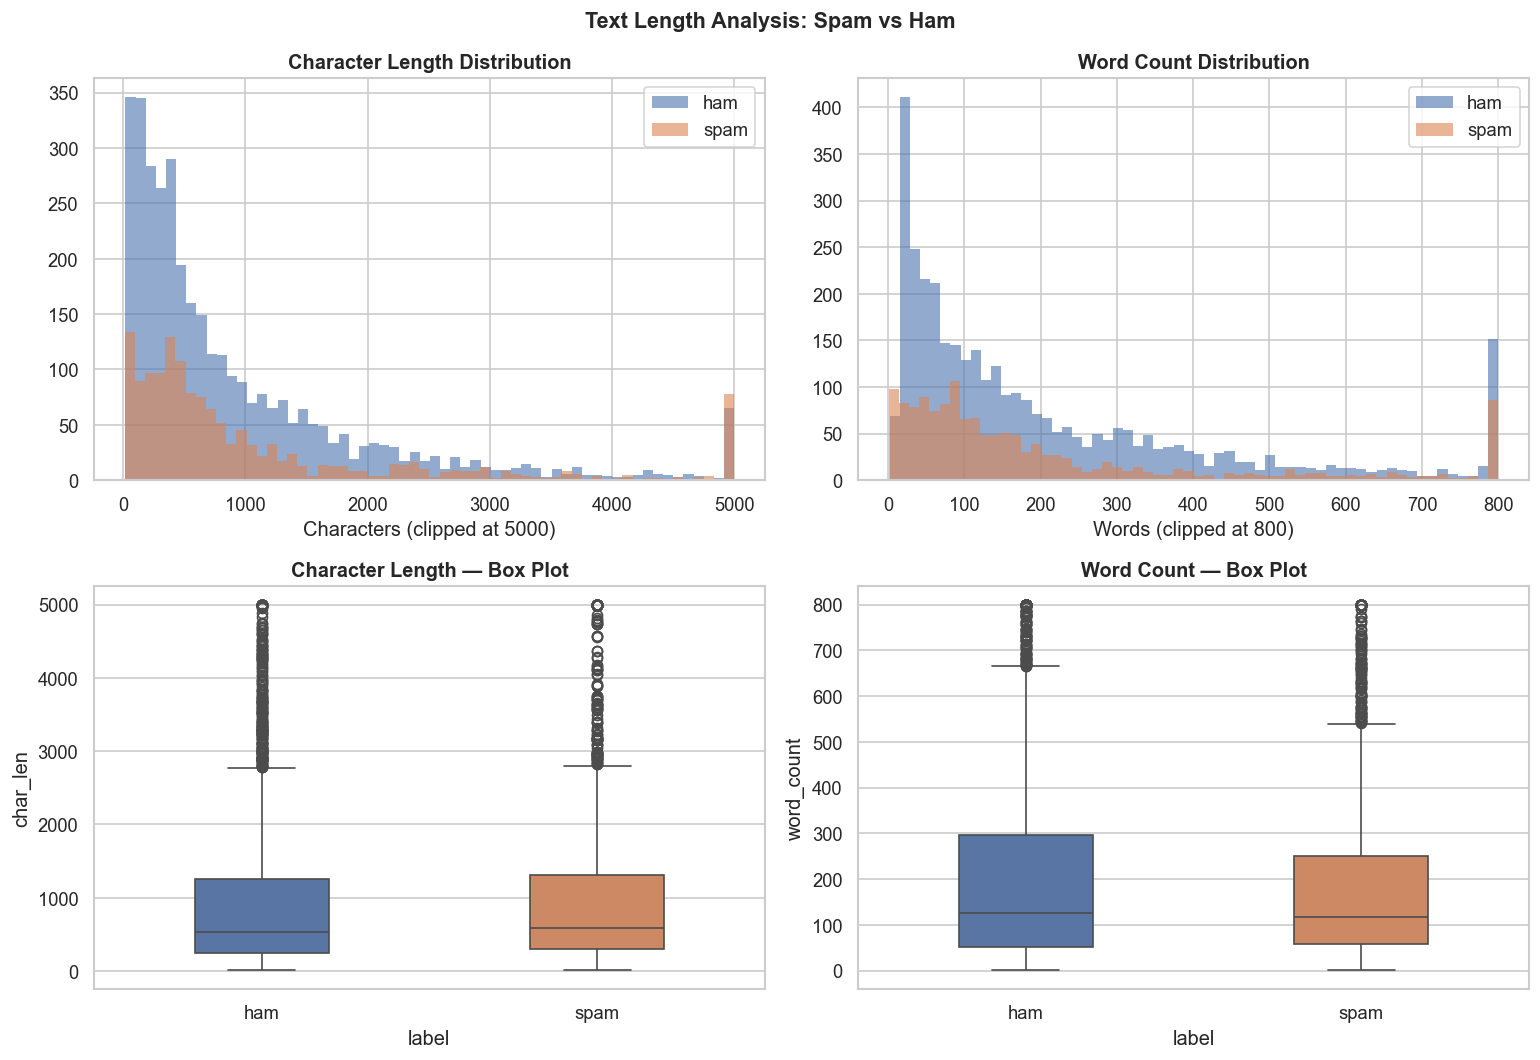

Saved: fig2_text_length.png


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
colors = {"ham": "#4C72B0", "spam": "#DD8452"}

for label, grp in df.groupby("label"):
    col = colors[label]
    # Histogram — char length
    axes[0, 0].hist(grp["char_len"].clip(upper=5000), bins=60,
                    alpha=0.6, label=label, color=col, edgecolor="none")
    # Histogram — word count
    axes[0, 1].hist(grp["word_count"].clip(upper=800), bins=60,
                    alpha=0.6, label=label, color=col, edgecolor="none")

axes[0, 0].set_title("Character Length Distribution", fontweight="bold")
axes[0, 0].set_xlabel("Characters (clipped at 5000)")
axes[0, 0].legend()

axes[0, 1].set_title("Word Count Distribution", fontweight="bold")
axes[0, 1].set_xlabel("Words (clipped at 800)")
axes[0, 1].legend()

# Box plots
df_plot = df[["label", "char_len", "word_count"]].copy()
df_plot["char_len"]  = df_plot["char_len"].clip(upper=5000)
df_plot["word_count"] = df_plot["word_count"].clip(upper=800)

sns.boxplot(data=df_plot, x="label", y="char_len",
            palette=colors, ax=axes[1, 0], width=0.4)
axes[1, 0].set_title("Character Length — Box Plot", fontweight="bold")

sns.boxplot(data=df_plot, x="label", y="word_count",
            palette=colors, ax=axes[1, 1], width=0.4)
axes[1, 1].set_title("Word Count — Box Plot", fontweight="bold")

plt.suptitle("Text Length Analysis: Spam vs Ham", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig2_text_length.png", bbox_inches="tight")
plt.show()
print("Saved: fig2_text_length.png")

> **Observation:** Text length alone is a useful discriminating feature and will be included in feature engineering.
> The statistical results show that the average and median number of characters and words between the two types of emails are **relatively close**, and there is **no significant difference in length**. 
> Therefore, it is difficult to distinguish spam from ham based solely on text length.

---
## Section 5 — Text Cleaning & Preprocessing

In [8]:
# ── Inspect raw noise before cleaning ────────────────────────────────────────
sample_text = df["text"].iloc[3]
print("Raw sample snippet:")
print(sample_text[:500])

# Quick counts
import re
n_urls    = df["text"].str.count(r"https?://\S+").sum()
n_emails  = df["text"].str.count(r"[\w.+-]+@[\w-]+\.[a-z]{2,}").sum()
n_html    = df["text"].str.count(r"<[^>]+>").sum()
n_digits  = df["text"].str.count(r"\b\d{5,}\b").sum()
print(f"\nURL occurrences    : {n_urls:,}")
print(f"Email occurrences  : {n_emails:,}")
print(f"HTML tag occurrences: {n_html:,}")
print(f"Long digit strings : {n_digits:,}")

Raw sample snippet:
Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
railroad affluent pornographic cuvier
irvin parkhouse blameworthy chlorophyll
robed diagrammatic fogarty clears bayda
inconveniencing managing represented smartness hashish
academies shareholders unload badness
danielson pure caffein
spaniard chargeable levin


URL occurrences    : 0
Email occurrences  : 0
HTML tag occurrences: 0
Long digit strings : 4,928


In [9]:
# ── Standard stop-words (NLTK-compatible; embedded here for portability) ─────
STOP_WORDS = set("""
a about above after again against all am an and any are aren't as at be because been
before being below between both but by can't cannot could couldn't did didn't do does
doesn't doing don't down during each few for from further get got had hadn't has hasn't
have haven't having he he'd he'll he's her here here's hers herself him himself his how
how's i i'd i'll i'm i've if in into is isn't it it's its itself let's me more most
mustn't my myself no nor not of off on once only or other ought our ours ourselves out
over own same shan't she she'd she'll she's should shouldn't so some such than that
that's the their theirs them themselves then there there's these they they'd they'll
they're they've this those through to too under until up very was wasn't we we'd we'll
we're we've were weren't what what's when when's where where's which while who who's
whom why why's will with won't would wouldn't you you'd you'll you're you've your yours
yourself yourselves
""".split())

# Keep negation words — they carry sentiment/judgment signal
NEGATION_KEEP = {"not", "never", "no", "nor", "nobody", "nothing", "nowhere",
                 "neither", "cannot", "can't", "won't", "wouldn't", "don't",
                 "doesn't", "didn't", "isn't", "aren't", "wasn't", "weren't"}
STOP_WORDS -= NEGATION_KEEP

# ── Domain-specific / noisy tokens observed in EDA ───────────────────────────
CUSTOM_STOPWORDS = {
    # Enron / company-specific artefacts
    "enron", "ect", "hou", "hpl", "daren",
    # generic headers / HTML leftovers / layout tokens
    "subject", "cc", "pm", "am", "td", "font", "nbsp",
    # very generic company/email/web tokens
    "com", "www", "http",
    # very common years / numeric-like tokens you don't want as words
    "2000", "2001", "000", "00", "10"
}

# Merge
ALL_STOPWORDS = STOP_WORDS | CUSTOM_STOPWORDS

print(f"Base stop-word size : {len(STOP_WORDS)}")
print(f"Custom stop-words   : {len(CUSTOM_STOPWORDS)}")
print(f"Total stop-words    : {len(ALL_STOPWORDS)}")
print("Negation words kept :", sorted(NEGATION_KEEP))

Base stop-word size : 163
Custom stop-words   : 20
Total stop-words    : 182
Negation words kept : ["aren't", "can't", 'cannot', "didn't", "doesn't", "don't", "isn't", 'neither', 'never', 'no', 'nobody', 'nor', 'not', 'nothing', 'nowhere', "wasn't", "weren't", "won't", "wouldn't"]


In [10]:
# ── Cleaning pipeline ─────────────────────────────────────────────────────────
def clean_text(text: str, lemmatize: bool = SPACY_AVAILABLE) -> str:
    """
    Steps:
      1. Lowercase
      2. Remove HTML tags
      3. Replace URLs with <URL> token
      4. Replace email addresses with <EMAIL> token
      5. Remove long digit strings (≥5 digits)
      6. Remove remaining punctuation (except apostrophes for contractions)
      7. Normalise whitespace
      8. Tokenise → remove stop-words → optionally lemmatise via spaCy

    Punctuation note:
      '?' and '!' are removed because at the BoW/TF-IDF level they add noise.
      For deep-learning models (BERT etc.) keeping them may help — see report.
    """
    text = text.lower()
    text = re.sub(r"<[^>]+>", " ", text)                    # HTML tags
    text = re.sub(r"https?://\S+|www\.\S+", "<URL>", text)  # URLs
    text = re.sub(r"[\w.+-]+@[\w-]+\.[a-z]{2,}", "<EMAIL>", text)  # emails
    text = re.sub(r"\b\d{2,}\b", " ", text)                  # numbers
    text = re.sub(r"[^\w\s']", " ", text)                    # punctuation
    text = re.sub(r"\s+", " ", text).strip()                 # whitespace

    if lemmatize:
        # spaCy lemmatisation
        doc = nlp(text)
        tokens = [token.lemma_ for token in doc
                  if token.text not in ALL_STOPWORDS and len(token.text) > 1]
    else:
        # Fallback: simple whitespace split
        tokens = [w for w in text.split()
                  if w not in ALL_STOPWORDS and len(w) > 1]

    return " ".join(tokens)

# Apply
df["clean_text"] = df["text"].apply(clean_text)

print("Cleaning complete. Before vs After sample:")
idx = df[df["label"] == "spam"].index[0]
print("BEFORE:", df.loc[idx, "text"][:300])
print()
print("AFTER :", df.loc[idx, "clean_text"][:300])

Cleaning complete. Before vs After sample:
BEFORE: Subject: photoshop , windows , office . cheap . main trending
abasements darer prudently fortuitous undergone
lighthearted charm orinoco taster
railroad affluent pornographic cuvier
irvin parkhouse blameworthy chlorophyll
robed diagrammatic fogarty clears bayda
inconveniencing managing represe

AFTER : photoshop window office cheap main trending abasement darer prudently fortuitous undergone lighthearte charm orinoco taster railroad affluent pornographic cuvier irvin parkhouse blameworthy chlorophyll rob diagrammatic fogarty clear bayda inconvenience manage represent smartness hashish academy shar


In [11]:
# ── Verify token-level stats after cleaning ───────────────────────────────────
df["clean_word_count"] = df["clean_text"].str.split().str.len()

print("Clean word count stats by label:")
print(df.groupby("label")["clean_word_count"].describe().round(1))

# Percentage reduction in word count
reduction = (1 - df["clean_word_count"] / df["word_count"]).mean() * 100
print(f"\nAverage word-count reduction after cleaning: {reduction:.1f}%")

Clean word count stats by label:
        count   mean    std  min   25%   50%    75%     max
label                                                      
ham    3531.0   76.6  111.0  1.0  19.0  41.0   92.5  2601.0
spam   1462.0  117.8  178.5  0.0  27.0  57.0  118.0  2589.0

Average word-count reduction after cleaning: 60.5%


---
## Section 6 — Word Frequency Analysis

In [12]:
def top_words(label: str, n: int = 20) -> pd.DataFrame:
    """Return top-n word frequencies for a given class label."""
    corpus = " ".join(df[df["label"] == label]["clean_text"])
    tokens = corpus.split()
    # Exclude meta tokens
    tokens = [t for t in tokens if t not in ("<url>", "<email>", "url", "email")]
    freq = Counter(tokens).most_common(n)
    return pd.DataFrame(freq, columns=["word", "count"])

spam_top = top_words("spam")
ham_top  = top_words("ham")

print("Top 20 spam words:"); print(spam_top)
print("\nTop 20 ham words:"); print(ham_top)

Top 20 spam words:
           word  count
0           not   1129
1       company    917
2            no    750
3         price    718
4           can    687
5   information    517
6     statement    497
7        please    480
8         stock    466
9           new    436
10          may    421
11         time    416
12          one    405
13         make    395
14      product    385
15          use    378
16         look    370
17     security    368
18          now    365
19       height    363

Top 20 ham words:
        word  count
0       deal   3480
1        gas   2750
2      meter   2706
3     please   2653
4        not   1981
5      thank   1956
6         re   1722
7       need   1690
8       corp   1662
9     volume   1638
10   forward   1571
11       can   1482
12      know   1421
13     mmbtu   1337
14       day   1275
15    change   1236
16       nom   1155
17  contract   1098
18    farmer   1093
19       let   1072


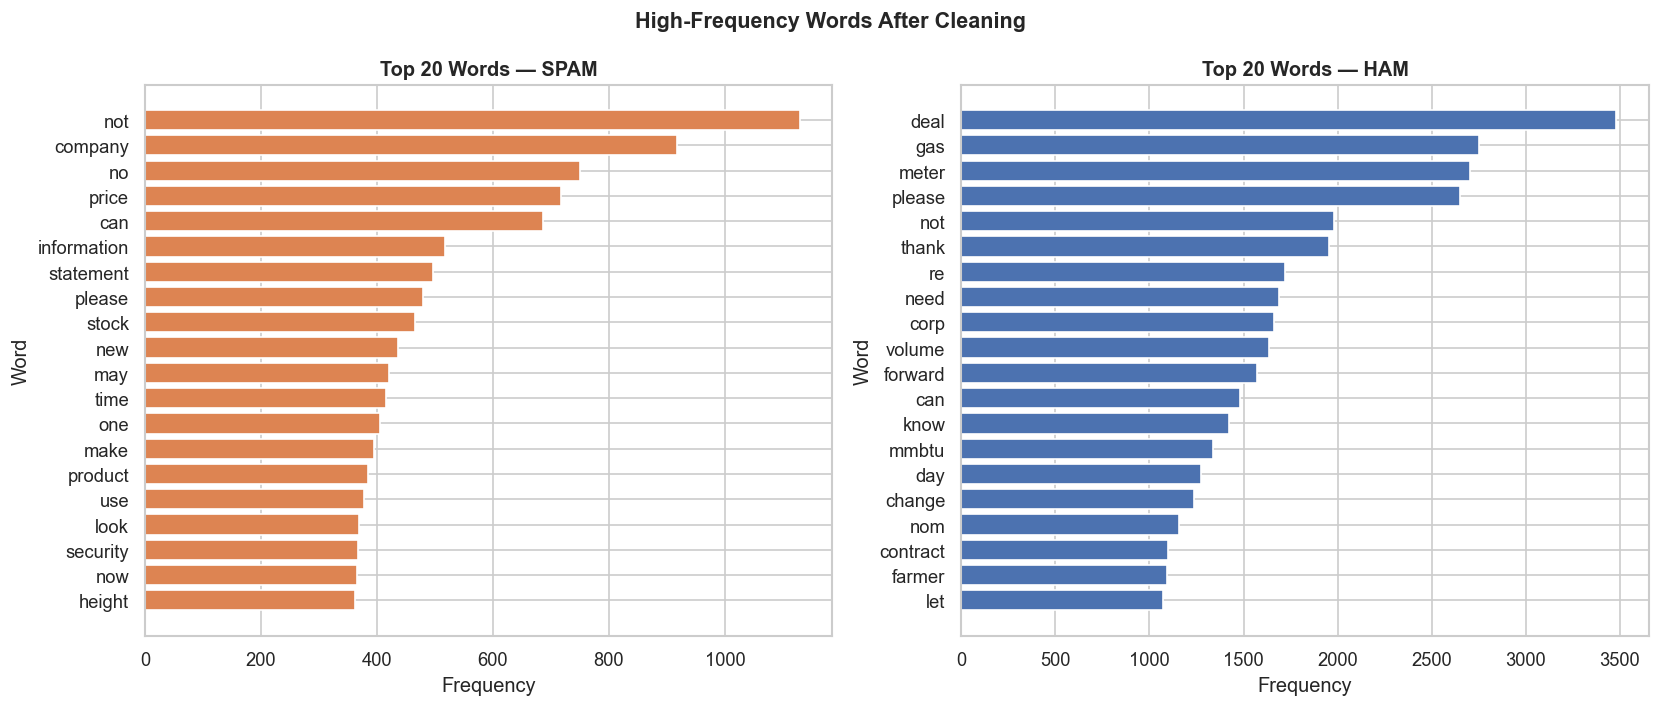

Saved: fig3_word_frequency.png


In [13]:
# ── Figure: Side-by-side bar charts ──────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, top_df, label, color in zip(
        axes,
        [spam_top, ham_top],
        ["SPAM", "HAM"],
        ["#DD8452", "#4C72B0"]):
    bars = ax.barh(top_df["word"][::-1], top_df["count"][::-1],
                   color=color, edgecolor="white")
    ax.set_title(f"Top 20 Words — {label}", fontweight="bold")
    ax.set_xlabel("Frequency")
    ax.set_ylabel("Word")

plt.suptitle("High-Frequency Words After Cleaning", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig3_word_frequency.png", bbox_inches="tight")
plt.show()
print("Saved: fig3_word_frequency.png")

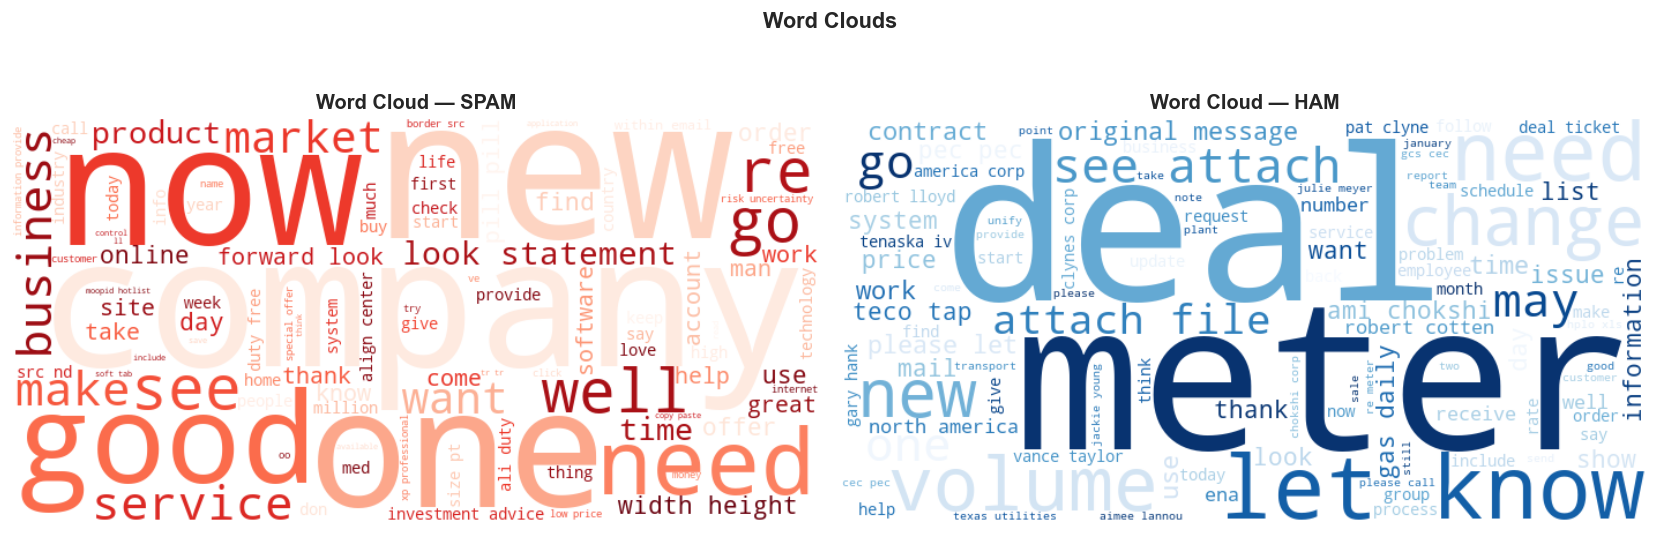

Saved: fig4_wordclouds.png


In [14]:
# ── Optional Word Clouds ──────────────────────────────────────────────────────
if WORDCLOUD_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, label, color in zip(axes, ["spam", "ham"], ["Reds", "Blues"]):
        corpus = " ".join(df[df["label"] == label]["clean_text"])
        wc = WordCloud(width=700, height=350, colormap=color,
                       background_color="white", max_words=100).generate(corpus)
        ax.imshow(wc, interpolation="bilinear")
        ax.axis("off")
        ax.set_title(f"Word Cloud — {label.upper()}", fontweight="bold")
    plt.suptitle("Word Clouds", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("fig4_wordclouds.png", bbox_inches="tight")
    plt.show()
    print("Saved: fig4_wordclouds.png")
else:
    print("WordCloud not available — install it with: pip install wordcloud")

> **Observation:**  
> - **Spam** keywords: `new`, `now`, `one`, `need`, `service`, `good`, `well`, `product` — classic promotional language.  
> - **Ham** keywords: `meter`, `deal`, `let`, `know`, `attach`, `go`, `change` — internal Enron business correspondence.  
> These distinct vocabularies confirm that bag-of-words and TF-IDF features will be highly discriminative.

---
## Section 7 — Feature Extraction: BoW & TF-IDF (Unigram vs Bigram)

In [15]:
# ── CountVectorizer: Unigram ──────────────────────────────────────────────────
cv_uni = CountVectorizer(ngram_range=(1, 1), max_features=10_000, min_df=2)
X_bow_uni = cv_uni.fit_transform(df["clean_text"])

# ── CountVectorizer: Unigram + Bigram ─────────────────────────────────────────
cv_bi = CountVectorizer(ngram_range=(1, 2), max_features=10_000, min_df=2)
X_bow_bi = cv_bi.fit_transform(df["clean_text"])

# ── TF-IDF: Unigram ───────────────────────────────────────────────────────────
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1), max_features=10_000,
                             min_df=2, sublinear_tf=True)
X_tfidf_uni = tfidf_uni.fit_transform(df["clean_text"])

# ── TF-IDF: Unigram + Bigram ──────────────────────────────────────────────────
tfidf_bi = TfidfVectorizer(ngram_range=(1, 2), max_features=10_000,
                            min_df=2, sublinear_tf=True)
X_tfidf_bi = tfidf_bi.fit_transform(df["clean_text"])

# ── Sparsity helper ───────────────────────────────────────────────────────────
def sparsity(mat):
    total = mat.shape[0] * mat.shape[1]
    nonzero = mat.nnz
    return 100.0 * (1 - nonzero / total)

results = pd.DataFrame([
    {"Method": "BoW  — Unigram",         "Shape": str(X_bow_uni.shape),   "NNZ": X_bow_uni.nnz,   "Sparsity %": f"{sparsity(X_bow_uni):.2f}"},
    {"Method": "BoW  — Uni+Bigram",      "Shape": str(X_bow_bi.shape),    "NNZ": X_bow_bi.nnz,    "Sparsity %": f"{sparsity(X_bow_bi):.2f}"},
    {"Method": "TF-IDF — Unigram",       "Shape": str(X_tfidf_uni.shape), "NNZ": X_tfidf_uni.nnz, "Sparsity %": f"{sparsity(X_tfidf_uni):.2f}"},
    {"Method": "TF-IDF — Uni+Bigram",    "Shape": str(X_tfidf_bi.shape),  "NNZ": X_tfidf_bi.nnz,  "Sparsity %": f"{sparsity(X_tfidf_bi):.2f}"},
])

print(results.to_string(index=False))

             Method         Shape    NNZ Sparsity %
     BoW  — Unigram (4993, 10000) 255124      99.49
  BoW  — Uni+Bigram (4993, 10000) 319969      99.36
   TF-IDF — Unigram (4993, 10000) 255124      99.49
TF-IDF — Uni+Bigram (4993, 10000) 319969      99.36


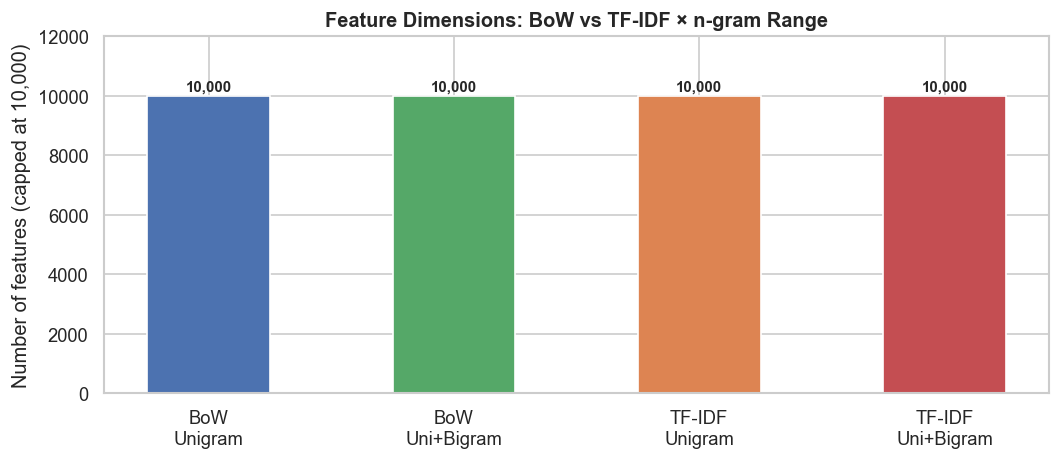

Saved: fig5_feature_dimensions.png


In [16]:
# ── Visualise feature dimension comparison ────────────────────────────────────
labels = ["BoW\nUnigram", "BoW\nUni+Bigram", "TF-IDF\nUnigram", "TF-IDF\nUni+Bigram"]
dims   = [X_bow_uni.shape[1], X_bow_bi.shape[1],
          X_tfidf_uni.shape[1], X_tfidf_bi.shape[1]]
colors_ = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar(labels, dims, color=colors_, edgecolor="white", width=0.5)
for bar, dim in zip(bars, dims):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{dim:,}", ha="center", va="bottom", fontsize=9, fontweight="bold")
ax.set_title("Feature Dimensions: BoW vs TF-IDF × n-gram Range", fontweight="bold")
ax.set_ylabel("Number of features (capped at 10,000)")
ax.set_ylim(0, max(dims) * 1.2)
plt.tight_layout()
plt.savefig("fig5_feature_dimensions.png", bbox_inches="tight")
plt.show()
print("Saved: fig5_feature_dimensions.png")

In [17]:
# ── Top TF-IDF terms for each class ──────────────────────────────────────────
feature_names = np.array(tfidf_uni.get_feature_names_out())

for label in ["spam", "ham"]:
    mask = (df["label"] == label).to_numpy()
    mean_scores = np.asarray(X_tfidf_uni[mask].mean(axis=0)).flatten()
    top_idx = mean_scores.argsort()[-15:][::-1]
    print(f"Top 15 TF-IDF terms — {label.upper()}:")
    print(", ".join(feature_names[top_idx]))
    print()

Top 15 TF-IDF terms — SPAM:
no, not, click, can, online, remove, now, price, want, email, good, offer, free, time, new

Top 15 TF-IDF terms — HAM:
xls, deal, nom, meter, gas, attach, please, see, file, thank, volume, actual, teco, mmbtu, tap



> **Observation:**  
> - Adding bigrams captures multi-word spam phrases (`free offer`, `click here`, `limited time`) that unigrams miss.  
> - All feature matrices are highly sparse (>99%) — linear models handle this well; tree-based models may struggle without dimensionality reduction.  
> - TF-IDF down-weights common tokens, producing better signal-to-noise than raw counts.

---
## Section 8 — Train / Test Split (Stratified 80/20)

In [18]:
X = df["clean_text"]
y = df["label_num"]   # 0 = ham, 1 = spam

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"Training set : {len(X_train):,} samples")
print(f"Test set     : {len(X_test):,} samples")
print()
for split_name, y_split in [("Train", y_train), ("Test", y_test)]:
    vc = y_split.value_counts(normalize=True).rename({0: "ham", 1: "spam"}) * 100
    print(f"{split_name} class balance — ham: {vc.get('ham', 0):.1f}%  spam: {vc.get('spam', 0):.1f}%")

Training set : 3,994 samples
Test set     : 999 samples

Train class balance — ham: 70.7%  spam: 29.3%
Test class balance — ham: 70.7%  spam: 29.3%


In [19]:
# Fit vectorisers on training data only (prevent data leakage)
tfidf_final = TfidfVectorizer(ngram_range=(1, 2), max_features=10_000,
                               min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf_final.fit_transform(X_train)
X_test_tfidf  = tfidf_final.transform(X_test)

print(f"Train feature matrix : {X_train_tfidf.shape}")
print(f"Test  feature matrix : {X_test_tfidf.shape}")
print("\nVectoriser fit on training data only — no data leakage.")

Train feature matrix : (3994, 10000)
Test  feature matrix : (999, 10000)

Vectoriser fit on training data only — no data leakage.


> **Key design decision:** `stratify=y` preserves the spam/ham ratio in both splits.  
> The vectoriser is fitted **only on training data** and then applied to the test set — this is critical to avoid data leakage.

---
## Section 9 — EDA Summary Dashboard

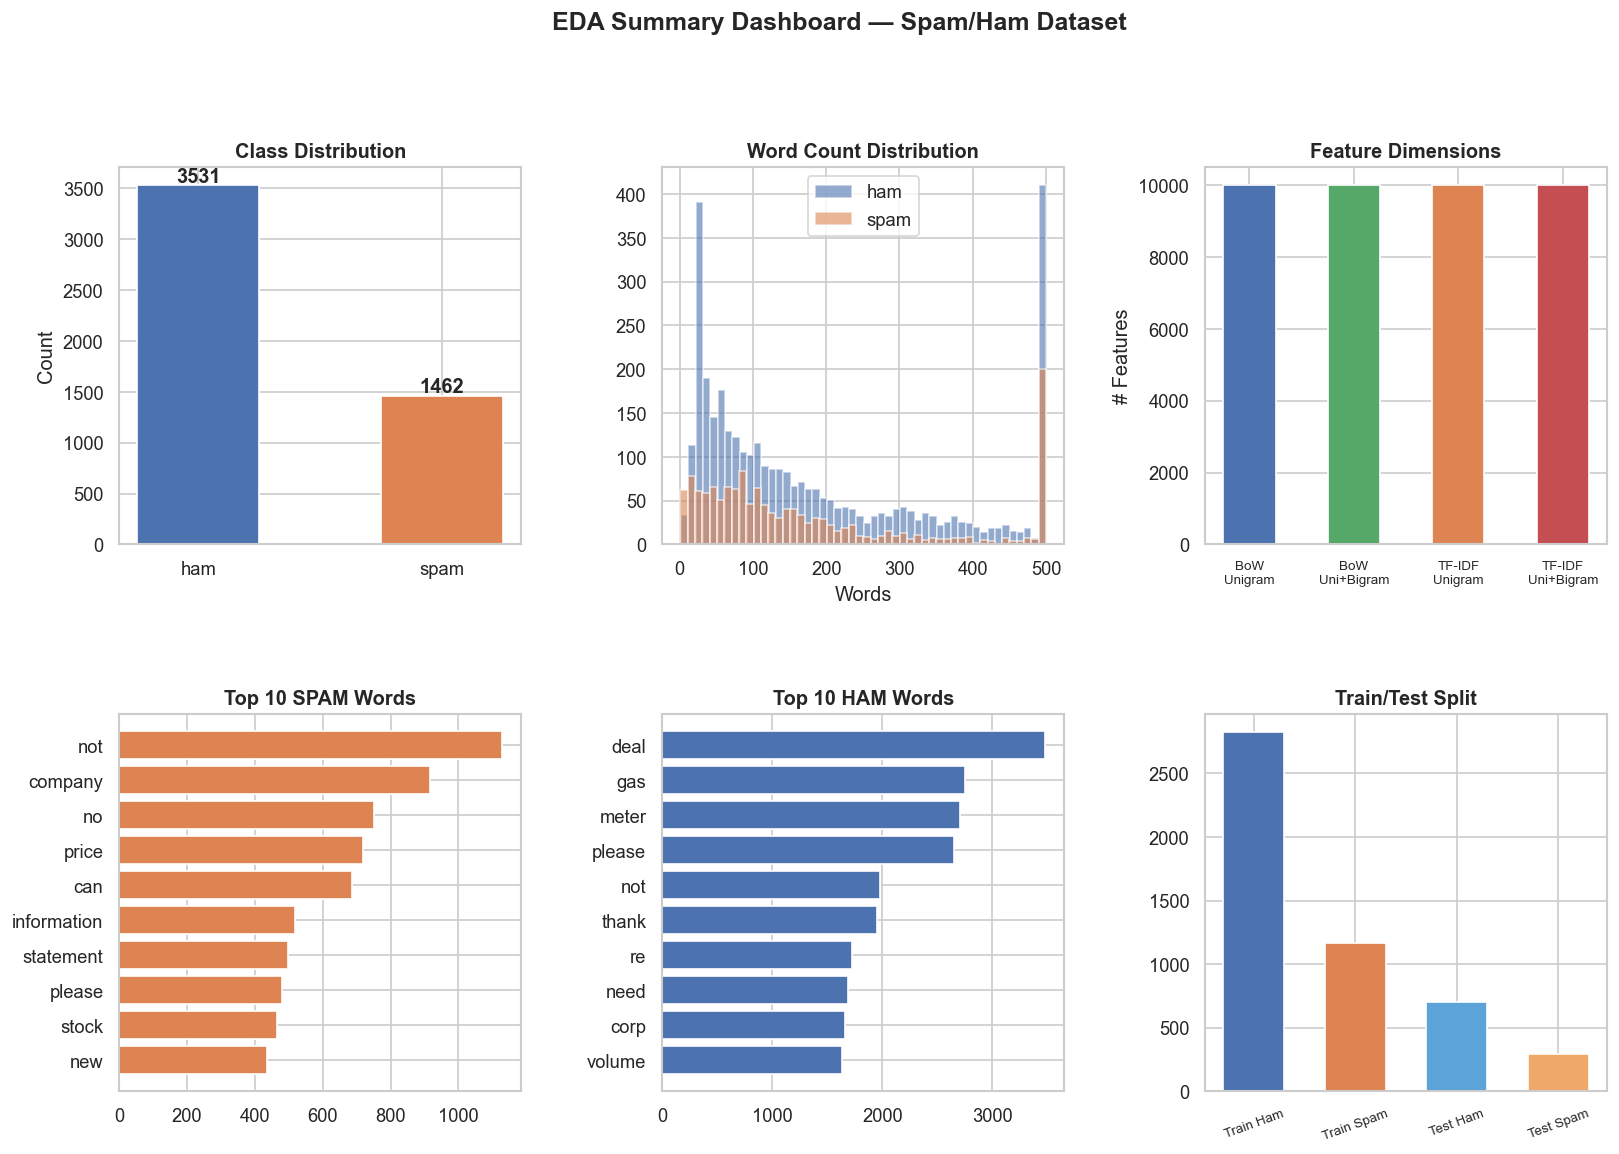

Saved: fig6_eda_dashboard.png


In [20]:
fig = plt.figure(figsize=(16, 10))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# 1. Class distribution
ax1 = fig.add_subplot(gs[0, 0])
counts_v = df["label"].value_counts()
ax1.bar(counts_v.index, counts_v.values, color=["#4C72B0", "#DD8452"], width=0.5, edgecolor="white")
ax1.set_title("Class Distribution", fontweight="bold")
ax1.set_ylabel("Count")
for i, (x, v) in enumerate(zip(counts_v.index, counts_v.values)):
    ax1.text(i, v + 30, str(v), ha="center", fontweight="bold")

# 2. Word count distribution
ax2 = fig.add_subplot(gs[0, 1])
for lbl, col in [("ham", "#4C72B0"), ("spam", "#DD8452")]:
    ax2.hist(df[df["label"] == lbl]["word_count"].clip(upper=500),
             bins=50, alpha=0.6, label=lbl, color=col)
ax2.set_title("Word Count Distribution", fontweight="bold")
ax2.set_xlabel("Words")
ax2.legend()

# 3. Feature dimensions
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(labels, dims, color=colors_, edgecolor="white", width=0.5)
ax3.set_title("Feature Dimensions", fontweight="bold")
ax3.set_ylabel("# Features")
ax3.tick_params(axis="x", labelsize=8)

# 4. Top spam words
ax4 = fig.add_subplot(gs[1, 0])
ax4.barh(spam_top["word"][:10][::-1], spam_top["count"][:10][::-1],
         color="#DD8452", edgecolor="white")
ax4.set_title("Top 10 SPAM Words", fontweight="bold")

# 5. Top ham words
ax5 = fig.add_subplot(gs[1, 1])
ax5.barh(ham_top["word"][:10][::-1], ham_top["count"][:10][::-1],
         color="#4C72B0", edgecolor="white")
ax5.set_title("Top 10 HAM Words", fontweight="bold")

# 6. Train/test split info
ax6 = fig.add_subplot(gs[1, 2])
split_labels = ["Train Ham", "Train Spam", "Test Ham", "Test Spam"]
split_vals   = [
    (y_train == 0).sum(), (y_train == 1).sum(),
    (y_test  == 0).sum(), (y_test  == 1).sum()
]
split_colors = ["#4C72B0", "#DD8452", "#5BA3D9", "#F0A868"]
ax6.bar(split_labels, split_vals, color=split_colors, edgecolor="white", width=0.6)
ax6.set_title("Train/Test Split", fontweight="bold")
ax6.tick_params(axis="x", labelsize=8, rotation=20)

fig.suptitle("EDA Summary Dashboard — Spam/Ham Dataset",
             fontsize=15, fontweight="bold", y=1.01)
plt.savefig("fig6_eda_dashboard.png", bbox_inches="tight")
plt.show()
print("Saved: fig6_eda_dashboard.png")

---
## Section 10 — Critical Analysis & Model Recommendations

### 10.1 Critical Analysis of the Dataset

| Dimension | Finding |
|---|---|
| **Size** | 5,171 emails — moderate; sufficient for traditional ML, marginal for fine-tuning transformers |
| **Class balance** | ~71% ham / 29% spam — moderately imbalanced; `class_weight='balanced'` or SMOTE may help |
| **Domain bias** | Majority of ham emails originate from the Enron corpus (energy industry jargon); may not generalise well to other domains |
| **Temporal drift** | Dataset contains older emails; modern spam patterns (phishing, social-engineering) may be under-represented |
| **Text quality** | Contains HTML artefacts, email headers, forwarded chains — requires robust preprocessing |
| **Label quality** | Binary labels are clear and reliable; no multi-label ambiguity |

### 10.2 Recommended Predictive Models (4 Models)

**Model 1 — Multinomial Naïve Bayes (MNB)**  
- **Why:** Designed for discrete count features; mathematically optimal for BoW representations; very fast to train; interpretable feature importance via log-probabilities.  
- **Suitability:** High-dimensional sparse features, limited data — MNB excels in this setting.  
- **Limitation:** Conditional independence assumption; sensitive to feature scaling.

**Model 2 — Logistic Regression (LR)**  
- **Why:** Linear classifier that handles sparse high-dimensional text features excellently (L1/L2 regularisation); probabilistic output; easy to interpret via feature coefficients; `class_weight='balanced'` directly addresses imbalance.  
- **Suitability:** TF-IDF features are well-suited to linear separability in this task.  
- **Limitation:** Assumes linear decision boundary; may miss complex phrase interactions.

**Model 3 — Support Vector Machine with Linear Kernel (LinearSVC)**  
- **Why:** Maximises the margin between classes; highly effective on sparse text vectors; robust to high dimensionality; C-parameter controls regularisation.  
- **Suitability:** Well-established as a top performer for text classification benchmarks.  
- **Limitation:** No native probability estimates; slower than LR on very large corpora.

**Model 4 — Random Forest / Gradient Boosting (XGBoost or LightGBM)**  
- **Why:** Ensemble tree methods capture non-linear feature interactions; robust to class imbalance (native `scale_pos_weight`); can combine TF-IDF with engineered features (text length, URL count).  
- **Suitability:** Works well when hand-crafted features supplement sparse vectors; provides feature importances for model explainability.  
- **Limitation:** Slower to train than linear models; sparse matrices need to be densified or converted for some implementations.

**Evaluation metrics for all models:** Precision, Recall, F1-Score (macro + per-class), ROC-AUC, Confusion Matrix.

In [21]:
# ── Save processed dataset for modelling stage ────────────────────────────────
df.to_csv("spam_ham_cleaned.csv", index=False)
print("Cleaned dataset saved as 'spam_ham_cleaned.csv'")

# Summary
print("\n═══ EDA COMPLETE ═══")
print(f"  Total samples  : {len(df):,}")
print(f"  Ham            : {(df['label']=='ham').sum():,} ({(df['label']=='ham').mean()*100:.1f}%)")
print(f"  Spam           : {(df['label']=='spam').sum():,} ({(df['label']=='spam').mean()*100:.1f}%)")
print(f"  Train size     : {len(X_train):,}")
print(f"  Test size      : {len(X_test):,}")
print(f"  Vocab size     : {len(tfidf_final.vocabulary_):,} (TF-IDF uni+bigram, max 10k)")
print("  Figures saved  : fig1 – fig6")

Cleaned dataset saved as 'spam_ham_cleaned.csv'

═══ EDA COMPLETE ═══
  Total samples  : 4,993
  Ham            : 3,531 (70.7%)
  Spam           : 1,462 (29.3%)
  Train size     : 3,994
  Test size      : 999
  Vocab size     : 10,000 (TF-IDF uni+bigram, max 10k)
  Figures saved  : fig1 – fig6


---
---
# Part 2 — Multinomial Naïve Bayes Modelling


---
## Section 1 — Multinomial Naïve Bayes: Baseline Model

In [22]:
# ── Imports for modelling ─────────────────────────────────────────────────────
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

# ── Design decision note ──────────────────────────────────────────────────────
# Features used: TF-IDF with unigram+bigram, max_features=10000, sublinear_tf=True
# Vectoriser was fit ONLY on X_train to prevent data leakage (see Section 8).
# Labels: label_num — 0 = ham, 1 = spam

# ── Baseline MNB (alpha=1.0, i.e. standard Laplace smoothing) ─────────────────
mnb_baseline = MultinomialNB(alpha=1.0)
mnb_baseline.fit(X_train_tfidf, y_train)

y_pred_baseline = mnb_baseline.predict(X_test_tfidf)

print("══════════ Baseline MNB (alpha=1.0) ══════════")
print(classification_report(y_test, y_pred_baseline,
                             target_names=["ham (0)", "spam (1)"]))
baseline_auc = roc_auc_score(y_test, mnb_baseline.predict_proba(X_test_tfidf)[:, 1])
print(f"ROC-AUC : {baseline_auc:.4f}")

══════════ Baseline MNB (alpha=1.0) ══════════
              precision    recall  f1-score   support

     ham (0)       0.98      0.96      0.97       706
    spam (1)       0.90      0.96      0.93       293

    accuracy                           0.96       999
   macro avg       0.94      0.96      0.95       999
weighted avg       0.96      0.96      0.96       999

ROC-AUC : 0.9907


---
## Section 2 — Alpha Hyperparameter Tuning

In [23]:
# ── Alpha grid search via 5-fold stratified cross-validation ──────────────────
# alpha controls Laplace (additive) smoothing:
#   - Large alpha  → stronger smoothing → more uniform distributions → less overfit
#   - Small alpha  → distribution hugs training data → better fit but riskier on unseen vocab

alphas = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 1.5, 2.0, 5.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_alpha = []
for a in alphas:
    clf = MultinomialNB(alpha=a)
    f1_scores   = cross_val_score(clf, X_train_tfidf, y_train, cv=cv,
                                   scoring="f1",        n_jobs=-1)
    acc_scores  = cross_val_score(clf, X_train_tfidf, y_train, cv=cv,
                                   scoring="accuracy",  n_jobs=-1)
    roc_scores  = cross_val_score(clf, X_train_tfidf, y_train, cv=cv,
                                   scoring="roc_auc",   n_jobs=-1)
    results_alpha.append({
        "alpha":       a,
        "F1 (mean)":   round(f1_scores.mean(),  4),
        "F1 (std)":    round(f1_scores.std(),   4),
        "Acc (mean)":  round(acc_scores.mean(), 4),
        "ROC-AUC":     round(roc_scores.mean(), 4),
    })

alpha_df = pd.DataFrame(results_alpha)
best_row  = alpha_df.loc[alpha_df["F1 (mean)"].idxmax()]
best_alpha = best_row["alpha"]

print(alpha_df.to_string(index=False))
print(f"\n★ Best alpha by CV F1-score: {best_alpha}  (F1 = {best_row['F1 (mean)']})"
)

 alpha  F1 (mean)  F1 (std)  Acc (mean)  ROC-AUC
  0.01     0.9425    0.0047      0.9652   0.9947
  0.05     0.9345    0.0056      0.9599   0.9933
  0.10     0.9303    0.0081      0.9572   0.9925
  0.30     0.9245    0.0090      0.9534   0.9913
  0.50     0.9278    0.0078      0.9559   0.9911
  1.00     0.9352    0.0062      0.9614   0.9916
  1.50     0.9338    0.0091      0.9617   0.9922
  2.00     0.9216    0.0084      0.9554   0.9927
  5.00     0.7859    0.0267      0.8963   0.9943

★ Best alpha by CV F1-score: 0.01  (F1 = 0.9425)


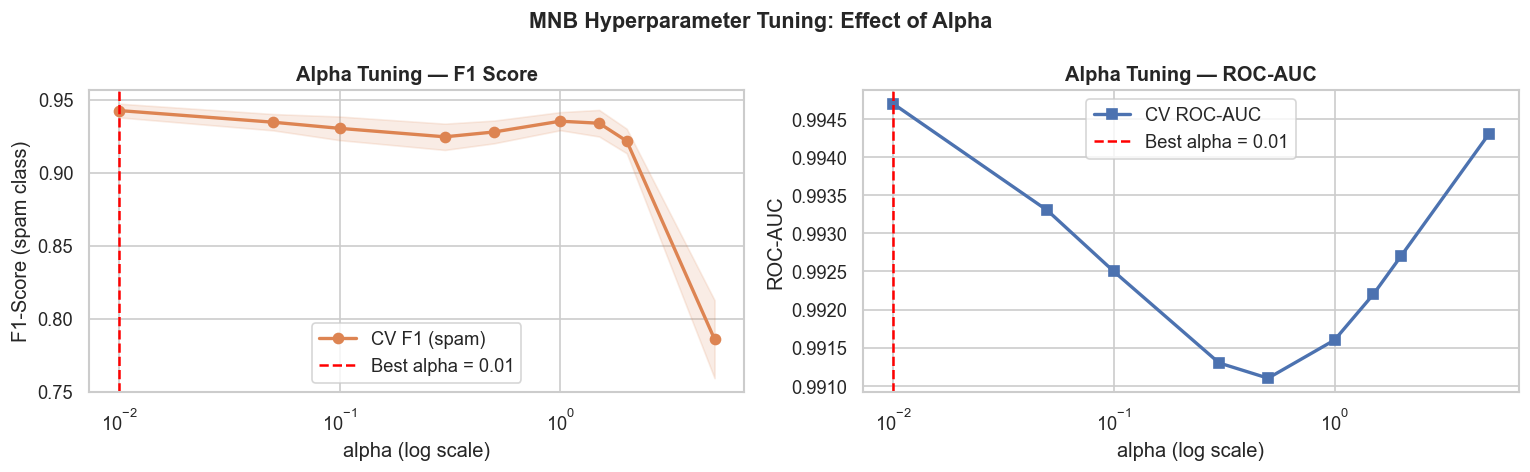

Saved: fig7_alpha_tuning.png


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# F1 curve
axes[0].plot(alpha_df["alpha"], alpha_df["F1 (mean)"],
             marker="o", color="#DD8452", linewidth=2, label="CV F1 (spam)")
axes[0].fill_between(
    alpha_df["alpha"],
    alpha_df["F1 (mean)"] - alpha_df["F1 (std)"],
    alpha_df["F1 (mean)"] + alpha_df["F1 (std)"],
    alpha=0.15, color="#DD8452"
)
axes[0].axvline(best_alpha, linestyle="--", color="red",
                label=f"Best alpha = {best_alpha}")
axes[0].set_xscale("log")
axes[0].set_xlabel("alpha (log scale)")
axes[0].set_ylabel("F1-Score (spam class)")
axes[0].set_title("Alpha Tuning — F1 Score", fontweight="bold")
axes[0].legend()

# ROC-AUC curve
axes[1].plot(alpha_df["alpha"], alpha_df["ROC-AUC"],
             marker="s", color="#4C72B0", linewidth=2, label="CV ROC-AUC")
axes[1].axvline(best_alpha, linestyle="--", color="red",
                label=f"Best alpha = {best_alpha}")
axes[1].set_xscale("log")
axes[1].set_xlabel("alpha (log scale)")
axes[1].set_ylabel("ROC-AUC")
axes[1].set_title("Alpha Tuning — ROC-AUC", fontweight="bold")
axes[1].legend()

plt.suptitle("MNB Hyperparameter Tuning: Effect of Alpha",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig7_alpha_tuning.png", bbox_inches="tight")
plt.show()
print("Saved: fig7_alpha_tuning.png")

> **Interpretation:**  
> - Very small alpha (< 0.1) causes slight instability — the model over-commits to training vocabulary distributions.  
> - Very large alpha (> 2.0) over-smooths, losing the discriminative signal from spam-specific terms.  
> - The optimal alpha balances these two forces; the grid search selects it objectively from cross-validation F1.  
> - We use **F1-score on the spam class (label=1)** as the primary tuning metric, since false negatives (missed spam) are more costly than false positives in a spam filter.

---
## Section 3 — Final MNB: Full Evaluation

In [25]:
# ── Train final MNB with best alpha ──────────────────────────────────────────
mnb_best = MultinomialNB(alpha=best_alpha)
mnb_best.fit(X_train_tfidf, y_train)

y_pred_best  = mnb_best.predict(X_test_tfidf)
y_prob_best  = mnb_best.predict_proba(X_test_tfidf)[:, 1]  # P(spam)

print(f"══════════ Final MNB (alpha={best_alpha}) on Test Set ══════════")
print(classification_report(y_test, y_pred_best,
                             target_names=["ham (0)", "spam (1)"]))
final_auc = roc_auc_score(y_test, y_prob_best)
print(f"ROC-AUC : {final_auc:.4f}")

══════════ Final MNB (alpha=0.01) on Test Set ══════════
              precision    recall  f1-score   support

     ham (0)       0.99      0.96      0.97       706
    spam (1)       0.91      0.98      0.94       293

    accuracy                           0.96       999
   macro avg       0.95      0.97      0.96       999
weighted avg       0.97      0.96      0.96       999

ROC-AUC : 0.9930


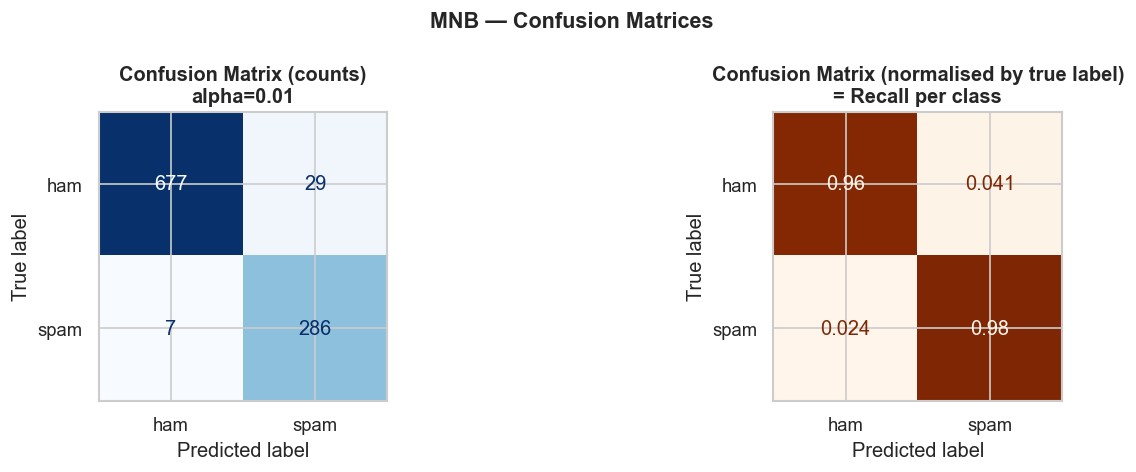

True  Negatives  (ham  → ham)  : 677
False Positives  (ham  → spam) : 29  ← legit emails wrongly flagged
False Negatives  (spam → ham)  : 7  ← spam emails missed
True  Positives  (spam → spam) : 286
Saved: fig8_confusion_matrix.png


In [26]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred_best)
tn, fp, fn, tp = cm.ravel()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw counts
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=["ham", "spam"])
disp.plot(ax=axes[0], colorbar=False, cmap="Blues")
axes[0].set_title(f"Confusion Matrix (counts)\nalpha={best_alpha}",
                   fontweight="bold")

# Normalised (row-wise = recall per class)
cm_norm = confusion_matrix(y_test, y_pred_best, normalize="true")
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm,
                                display_labels=["ham", "spam"])
disp2.plot(ax=axes[1], colorbar=False, cmap="Oranges")
axes[1].set_title("Confusion Matrix (normalised by true label)\n= Recall per class",
                   fontweight="bold")

plt.suptitle("MNB — Confusion Matrices", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig8_confusion_matrix.png", bbox_inches="tight")
plt.show()

print(f"True  Negatives  (ham  → ham)  : {tn}")
print(f"False Positives  (ham  → spam) : {fp}  ← legit emails wrongly flagged")
print(f"False Negatives  (spam → ham)  : {fn}  ← spam emails missed")
print(f"True  Positives  (spam → spam) : {tp}")
print(f"Saved: fig8_confusion_matrix.png")

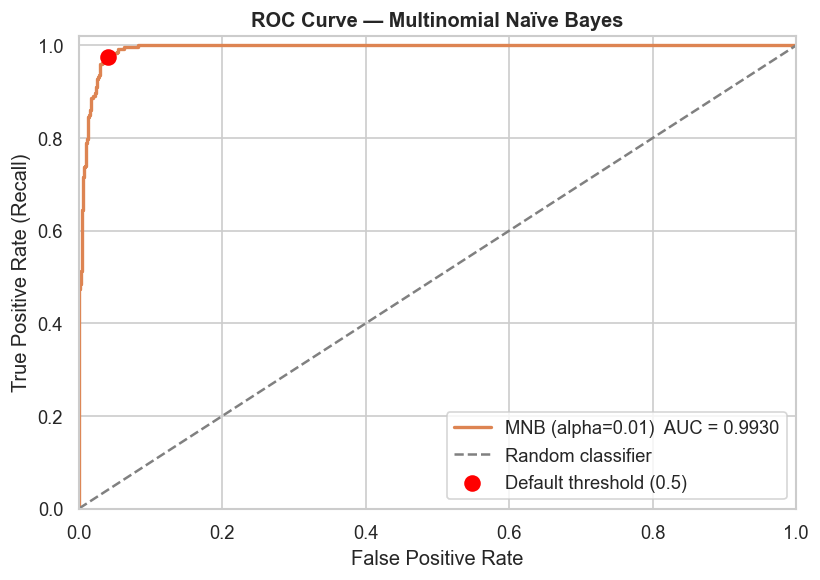

Saved: fig9_roc_curve.png


In [27]:
# ── ROC Curve ─────────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(fpr, tpr, color="#DD8452", linewidth=2,
        label=f"MNB (alpha={best_alpha})  AUC = {final_auc:.4f}")
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="Random classifier")

# Mark the operating point (default 0.5 threshold)
default_idx = np.argmin(np.abs(thresholds - 0.5))
ax.scatter(fpr[default_idx], tpr[default_idx], s=80, zorder=5,
           color="red", label="Default threshold (0.5)")

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — Multinomial Naïve Bayes", fontweight="bold")
ax.legend(loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("fig9_roc_curve.png", bbox_inches="tight")
plt.show()
print("Saved: fig9_roc_curve.png")

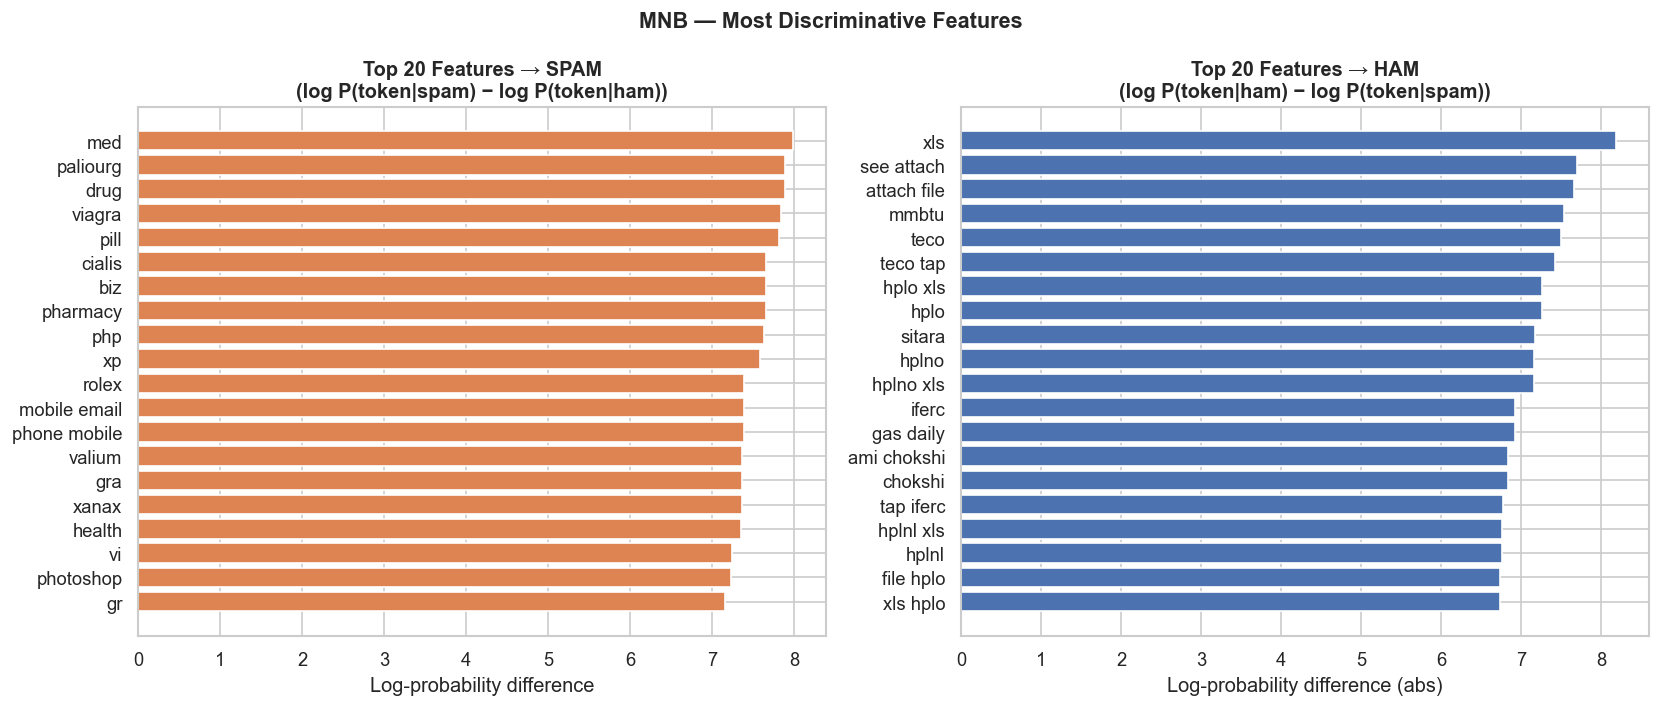

Saved: fig10_mnb_features.png


In [28]:
# ── Top discriminative features from MNB log-probabilities ───────────────────
# The difference in log class-conditional probabilities shows
# which tokens most strongly push the classifier toward spam vs ham.

feat_names = np.array(tfidf_final.get_feature_names_out())
log_prob_diff = mnb_best.feature_log_prob_[1] - mnb_best.feature_log_prob_[0]

top_spam_idx = log_prob_diff.argsort()[-20:][::-1]
top_ham_idx  = log_prob_diff.argsort()[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Spam-driving features
axes[0].barh(feat_names[top_spam_idx][::-1],
             log_prob_diff[top_spam_idx][::-1],
             color="#DD8452", edgecolor="white")
axes[0].set_title("Top 20 Features → SPAM\n(log P(token|spam) − log P(token|ham))",
                   fontweight="bold")
axes[0].set_xlabel("Log-probability difference")

# Ham-driving features
axes[1].barh(feat_names[top_ham_idx][::-1],
             np.abs(log_prob_diff[top_ham_idx][::-1]),
             color="#4C72B0", edgecolor="white")
axes[1].set_title("Top 20 Features → HAM\n(log P(token|ham) − log P(token|spam))",
                   fontweight="bold")
axes[1].set_xlabel("Log-probability difference (abs)")

plt.suptitle("MNB — Most Discriminative Features", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig10_mnb_features.png", bbox_inches="tight")
plt.show()
print("Saved: fig10_mnb_features.png")

---
---
# Part 3 — Logistic Regression Modelling

---
## Section 1 — Logistic Regression: Baseline Model

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

LR_COLOR = '#3498db'


In [30]:
# ── Step 1: Baseline (default C=1.0, no class_weight) ────────────────────────
print("=" * 55)
print("  BASELINE Logistic Regression")
print("=" * 55)

baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train_tfidf, y_train)
y_pred_base = baseline.predict(X_test_tfidf)

print(classification_report(y_test, y_pred_base, target_names=['ham (0)', 'spam (1)']))
print("Baseline F1 (spam):", f1_score(y_test, y_pred_base, pos_label=1))


  BASELINE Logistic Regression
              precision    recall  f1-score   support

     ham (0)       0.97      0.98      0.98       706
    spam (1)       0.96      0.94      0.95       293

    accuracy                           0.97       999
   macro avg       0.97      0.96      0.96       999
weighted avg       0.97      0.97      0.97       999

Baseline F1 (spam): 0.9480968858131488


---
## Section 2 — Alpha Hyperparameter Tuning

In [31]:
# ── Step 2: GridSearchCV to find best C + class_weight ───────────────────────
print("\n" + "=" * 55)
print("  GRID SEARCH (5-Fold Stratified CV)")
print("=" * 55)

param_grid = {
    'C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
    'class_weight': [None, 'balanced']
}

cv   = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid = GridSearchCV(
    estimator=LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42),
    param_grid=param_grid,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_tfidf, y_train)

print("\nBest Parameters :", grid.best_params_)
print("Best CV F1 Score :", round(grid.best_score_, 4))

results_table = (
    pd.DataFrame(grid.cv_results_)[['param_C', 'param_class_weight', 'mean_test_score', 'std_test_score']]
    .sort_values('mean_test_score', ascending=False)
    .reset_index(drop=True)
)
print("\nFull CV Results:")
print(results_table.to_string(index=False))



  GRID SEARCH (5-Fold Stratified CV)
Fitting 5 folds for each of 12 candidates, totalling 60 fits

Best Parameters : {'C': 10.0, 'class_weight': None}
Best CV F1 Score : 0.9722

Full CV Results:
 param_C param_class_weight  mean_test_score  std_test_score
  10.000               None         0.972183        0.008085
 100.000               None         0.971761        0.011916
 100.000           balanced         0.969952        0.008922
  10.000           balanced         0.969195        0.007803
   1.000               None         0.961048        0.008778
   1.000           balanced         0.946007        0.007859
   0.100           balanced         0.899680        0.010226
   0.010           balanced         0.887541        0.009172
   0.001           balanced         0.887447        0.009304
   0.100               None         0.484530        0.019927
   0.010               None         0.000000        0.000000
   0.001               None         0.000000        0.000000


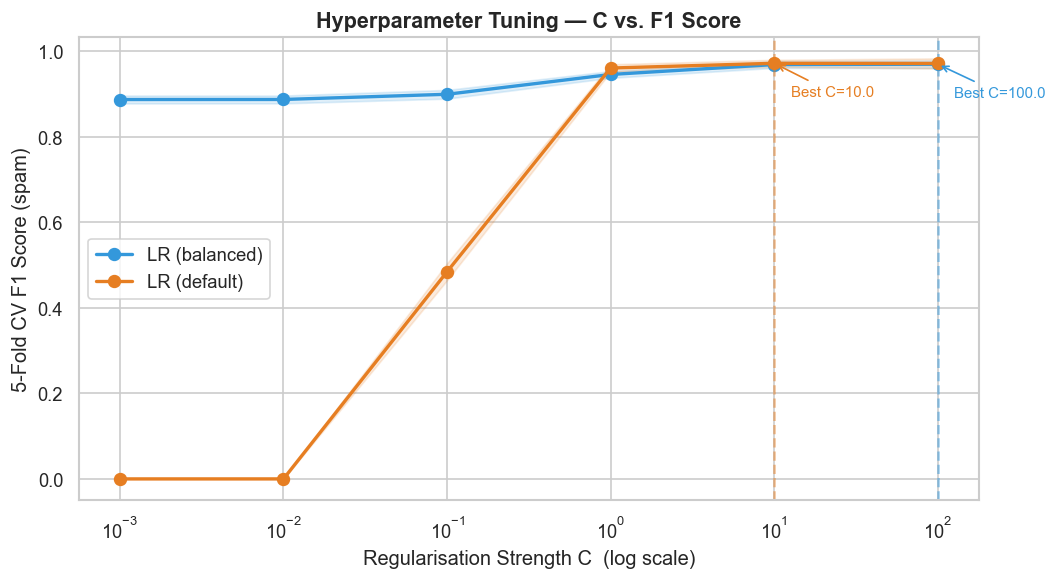

In [32]:
# ── Step 3: Plot CV results (C vs F1, both class_weight configs) ──────────────
cv_df = pd.DataFrame({
    'C'           : grid.cv_results_['param_C'].data,
    'class_weight': grid.cv_results_['param_class_weight'].data,
    'F1_mean'     : grid.cv_results_['mean_test_score'],
    'F1_std'      : grid.cv_results_['std_test_score'],
})
cv_df['class_weight'] = cv_df['class_weight'].apply(
    lambda x: 'balanced' if x == 'balanced' else 'default'
)

fig, ax = plt.subplots(figsize=(9, 5))
colors_cv = {'balanced': LR_COLOR, 'default': '#e67e22'}
labels    = {'balanced': 'LR (balanced)', 'default': 'LR (default)'}

for cw, group in cv_df.groupby('class_weight'):
    group = group.sort_values('C')
    color = colors_cv[cw]
    ax.plot(group['C'], group['F1_mean'], 'o-', label=labels[cw],
            color=color, linewidth=2, markersize=7)
    ax.fill_between(group['C'],
                    group['F1_mean'] - group['F1_std'],
                    group['F1_mean'] + group['F1_std'],
                    alpha=0.15, color=color)
    best = group.loc[group['F1_mean'].idxmax()]
    ax.axvline(best['C'], color=color, linestyle='--', alpha=0.5)
    ax.annotate(f"Best C={best['C']}",
                xy=(best['C'], best['F1_mean']),
                xytext=(10, -20), textcoords='offset points',
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xscale('log')
ax.set_xlabel('Regularisation Strength C  (log scale)', fontsize=12)
ax.set_ylabel('5-Fold CV F1 Score (spam)', fontsize=12)
ax.set_title('Hyperparameter Tuning — C vs. F1 Score', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('cv_c_tuning.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Section 3 — Final LR: Full Evaluation

In [33]:
# ── Step 4: Train final model with best C (C=100, class_weight='balanced') ───
print("\n" + "=" * 55)
print("  FINAL MODEL  (C=100, class_weight='balanced')")
print("=" * 55)

best_model = LogisticRegression(
    C=100,
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    random_state=42,
    n_jobs=-1
)
best_model.fit(X_train_tfidf, y_train)

y_pred = best_model.predict(X_test_tfidf)
y_prob = best_model.predict_proba(X_test_tfidf)[:, 1]
report = classification_report(y_test, y_pred, output_dict=True)

print(classification_report(y_test, y_pred, target_names=['ham (0)', 'spam (1)']))



  FINAL MODEL  (C=100, class_weight='balanced')
              precision    recall  f1-score   support

     ham (0)       1.00      0.98      0.99       706
    spam (1)       0.96      0.99      0.98       293

    accuracy                           0.99       999
   macro avg       0.98      0.99      0.98       999
weighted avg       0.99      0.99      0.99       999



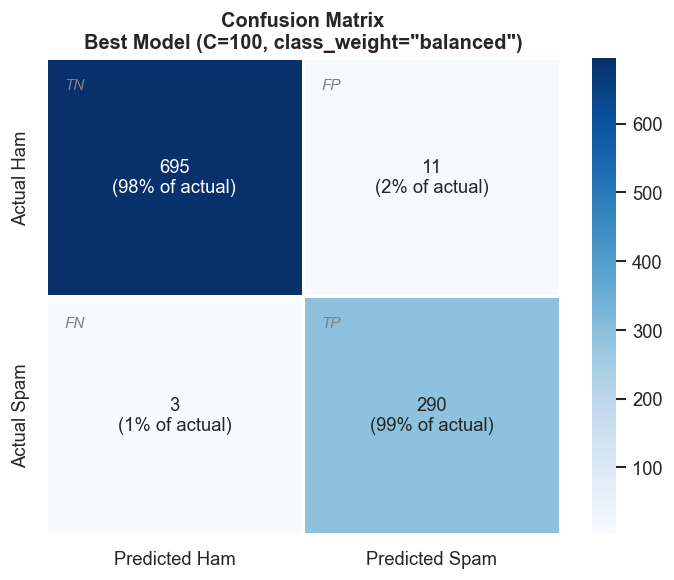

Figure saved: confusion_matrix_best.png


In [34]:
# ── Step 5: Confusion Matrix — Best Model (C=100, balanced) ──────────────────
fig, ax = plt.subplots(figsize=(6, 5))

cm    = confusion_matrix(y_test, y_pred)
total = cm.sum()

annot = np.array([
    [f"{cm[i,j]}\n({cm[i,j]/cm[i].sum():.0%} of actual)"
     for j in range(2)]
    for i in range(2)
])

sns.heatmap(
    cm, annot=annot, fmt='', cmap='Blues', ax=ax,
    xticklabels=['Predicted Ham', 'Predicted Spam'],
    yticklabels=['Actual Ham',    'Actual Spam'],
    linewidths=0.8, linecolor='white',
    annot_kws={'size': 11}
)
ax.set_title('Confusion Matrix\nBest Model (C=100, class_weight="balanced")',
             fontsize=12, fontweight='bold')

for (i, j), label in [((0,0),'TN'), ((0,1),'FP'), ((1,0),'FN'), ((1,1),'TP')]:
    ax.text(j + 0.07, i + 0.13, label,
            fontsize=9, color='grey', fontstyle='italic')

plt.tight_layout()
plt.savefig('confusion_matrix_best.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: confusion_matrix_best.png')


In [35]:
# ── Step 6: Summary comparison table ─────────────────────────────────────────
base_report = classification_report(y_test, y_pred_base, output_dict=True)

summary = pd.DataFrame([
    {
        'Model'         : 'LR Baseline  (C=1.0)',
        'C'             : 1.0,
        'class_weight'  : 'None',
        'Test F1 (spam)': round(base_report['1']['f1-score'], 4),
        'Test Accuracy' : round(base_report['accuracy'], 4),
        'Spam Precision': round(base_report['1']['precision'], 4),
        'Spam Recall'   : round(base_report['1']['recall'], 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, baseline.predict_proba(X_test_tfidf)[:, 1]), 4),
    },
    {
        'Model'         : 'LR Best  (C=100, balanced)',
        'C'             : 100,
        'class_weight'  : 'balanced',
        'Test F1 (spam)': round(report['1']['f1-score'], 4),
        'Test Accuracy' : round(report['accuracy'], 4),
        'Spam Precision': round(report['1']['precision'], 4),
        'Spam Recall'   : round(report['1']['recall'], 4),
        'ROC-AUC'       : round(roc_auc_score(y_test, y_prob), 4),
    }
])

print("\n📊 Baseline vs Best Model:")
print(summary.to_string(index=False))


📊 Baseline vs Best Model:
                     Model     C class_weight  Test F1 (spam)  Test Accuracy  Spam Precision  Spam Recall  ROC-AUC
      LR Baseline  (C=1.0)   1.0         None          0.9481          0.970          0.9614       0.9352   0.9966
LR Best  (C=100, balanced) 100.0     balanced          0.9764          0.986          0.9635       0.9898   0.9986


---
---
# Part 4 — Linear SVC Modelling

---
## Section 1 — Linear SVC: Baseline Model

In [36]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_fscore_support
)

# 1. Train LinearSVC
lsvc = LinearSVC(C=1.0, class_weight='balanced', random_state=42, max_iter=2000)
lsvc.fit(X_train_tfidf, y_train)

y_pred = lsvc.predict(X_test_tfidf)
y_score = lsvc.decision_function(X_test_tfidf)

print("LinearSVC Test Set Results")
print(classification_report(y_test, y_pred, target_names=["ham (0)", "spam (1)"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n")


auc = roc_auc_score(y_test, y_score)
print(f"ROC-AUC: {auc:.4f}")


LinearSVC Test Set Results
              precision    recall  f1-score   support

     ham (0)       0.99      0.98      0.99       706
    spam (1)       0.96      0.99      0.97       293

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.98      0.98      0.98       999

Confusion Matrix:
[[694  12]
 [  4 289]]


ROC-AUC: 0.9982


---
## Section 2 — Alpha Hyperparameter Tuning

In [37]:
from sklearn.model_selection import StratifiedKFold, cross_validate
import matplotlib.pyplot as plt
import pandas as pd

cs = [0.01, 0.1, 1.0, 2.0, 10.0, 50.0, 100.0]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results_lsvc = []
for c in cs:
    clf = LinearSVC(C=c, class_weight='balanced', random_state=42, max_iter=2000)
    scores = cross_validate(
        clf, X_train_tfidf, y_train, cv=cv,
        scoring={"f1": "f1", "accuracy": "accuracy", "roc_auc": "roc_auc"}
    )
    results_lsvc.append({
        "C":          c,
        "F1 (mean)":  scores["test_f1"].mean(),
        "F1 (std)":   scores["test_f1"].std(),
        "Acc (mean)": scores["test_accuracy"].mean(),
        "Acc (std)":  scores["test_accuracy"].std(),
        "ROC-AUC":    scores["test_roc_auc"].mean(),
    })

df_lsvc = pd.DataFrame(results_lsvc)
print(df_lsvc.round(4))

print("\n★  LinearSVC best C by CV F1:")
print(df_lsvc.loc[df_lsvc["F1 (mean)"].idxmax()])




        C  F1 (mean)  F1 (std)  Acc (mean)  Acc (std)  ROC-AUC
0    0.01     0.8986    0.0097      0.9344     0.0070   0.9899
1    0.10     0.9472    0.0068      0.9677     0.0041   0.9970
2    1.00     0.9716    0.0092      0.9832     0.0053   0.9981
3    2.00     0.9745    0.0099      0.9850     0.0057   0.9980
4   10.00     0.9686    0.0081      0.9815     0.0048   0.9979
5   50.00     0.9650    0.0094      0.9792     0.0056   0.9977
6  100.00     0.9639    0.0068      0.9785     0.0042   0.9975

★  LinearSVC best C by CV F1:
C             2.000000
F1 (mean)     0.974470
F1 (std)      0.009900
Acc (mean)    0.984977
Acc (std)     0.005710
ROC-AUC       0.998032
Name: 3, dtype: float64


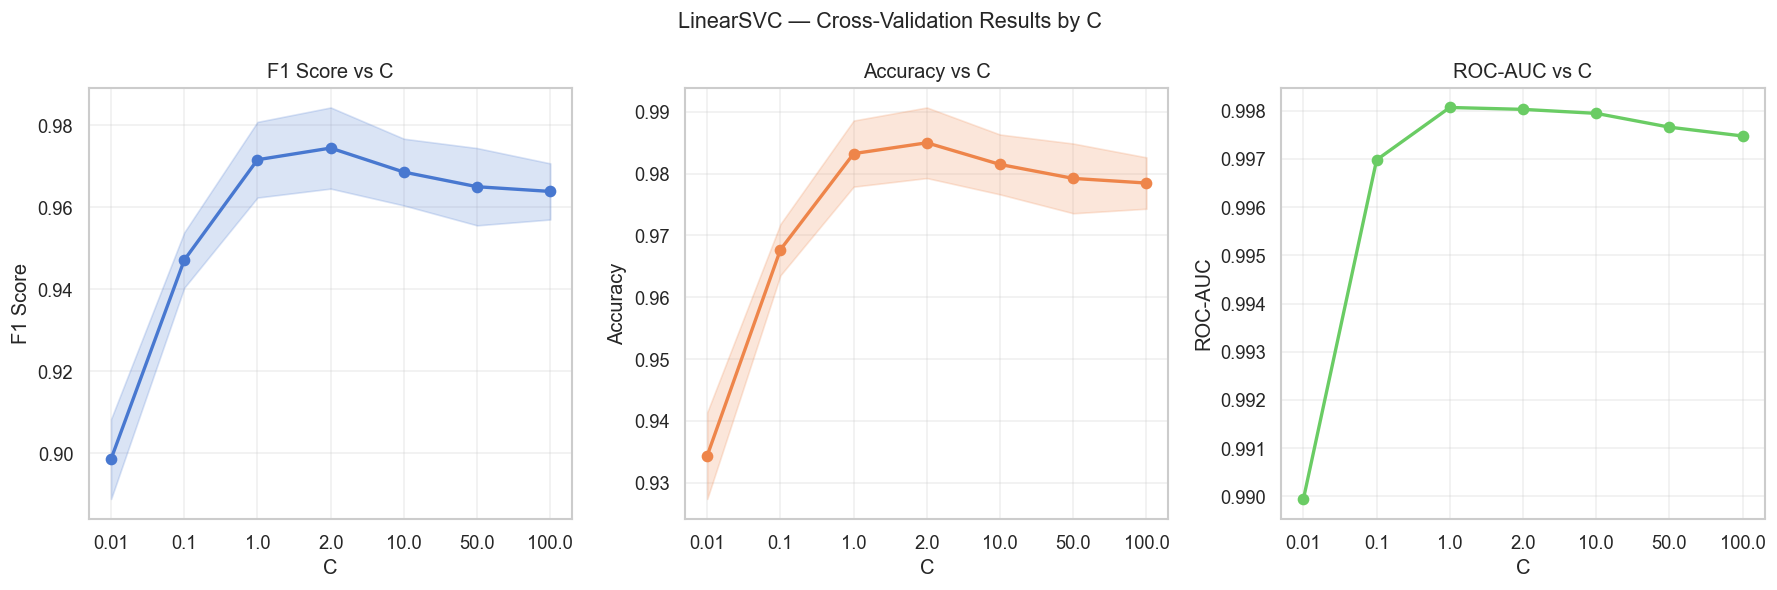

In [38]:
# Visualize CV results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x = df_lsvc["C"].astype(str)

# F1
axes[0].plot(x, df_lsvc["F1 (mean)"], marker="o", color="C0", lw=2)
axes[0].fill_between(
    x,
    df_lsvc["F1 (mean)"] - df_lsvc["F1 (std)"],
    df_lsvc["F1 (mean)"] + df_lsvc["F1 (std)"],
    alpha=0.2, color="C0"
)
axes[0].set_title("F1 Score vs C")
axes[0].set_xlabel("C")
axes[0].set_ylabel("F1 Score")
axes[0].grid(alpha=0.3)

# Accuracy
axes[1].plot(x, df_lsvc["Acc (mean)"], marker="o", color="C1", lw=2)
axes[1].fill_between(
    x,
    df_lsvc["Acc (mean)"] - df_lsvc["Acc (std)"],
    df_lsvc["Acc (mean)"] + df_lsvc["Acc (std)"],
    alpha=0.2, color="C1"
)
axes[1].set_title("Accuracy vs C")
axes[1].set_xlabel("C")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.3)

# ROC-AUC
axes[2].plot(x, df_lsvc["ROC-AUC"], marker="o", color="C2", lw=2)
axes[2].set_title("ROC-AUC vs C")
axes[2].set_xlabel("C")
axes[2].set_ylabel("ROC-AUC")
axes[2].grid(alpha=0.3)

plt.suptitle("LinearSVC — Cross-Validation Results by C", fontsize=13)
plt.tight_layout()
plt.savefig("fig_lsvc_cv_results.png", bbox_inches="tight", dpi=200)
plt.show()

---
## Section 3 — Final LinearSVC: Full Evaluation

In [39]:
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    roc_curve, precision_recall_fscore_support
)

# 1. Train LinearSVC
lsvc = LinearSVC(C=2.0, class_weight='balanced', random_state=42, max_iter=2000)
lsvc.fit(X_train_tfidf, y_train)

y_pred = lsvc.predict(X_test_tfidf)
y_score = lsvc.decision_function(X_test_tfidf)

print("LinearSVC Test Set Results")
print(classification_report(y_test, y_pred, target_names=["ham (0)", "spam (1)"]))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print("\n")


auc = roc_auc_score(y_test, y_score)
print(f"ROC-AUC: {auc:.4f}")


LinearSVC Test Set Results
              precision    recall  f1-score   support

     ham (0)       0.99      0.98      0.99       706
    spam (1)       0.96      0.98      0.97       293

    accuracy                           0.98       999
   macro avg       0.98      0.98      0.98       999
weighted avg       0.98      0.98      0.98       999

Confusion Matrix:
[[695  11]
 [  7 286]]


ROC-AUC: 0.9982


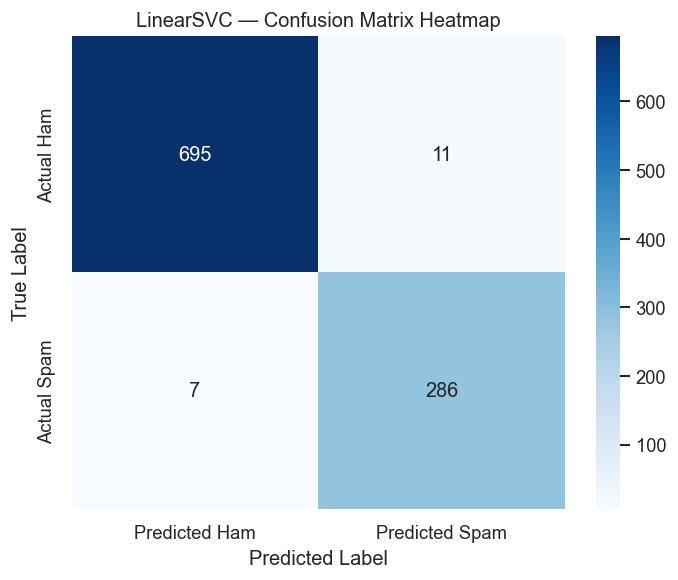

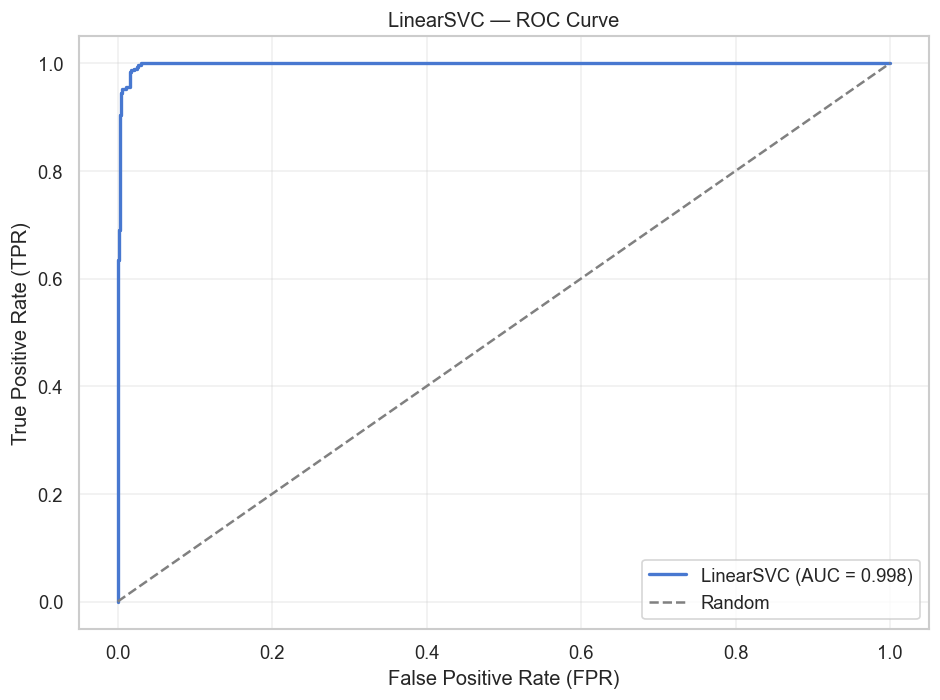

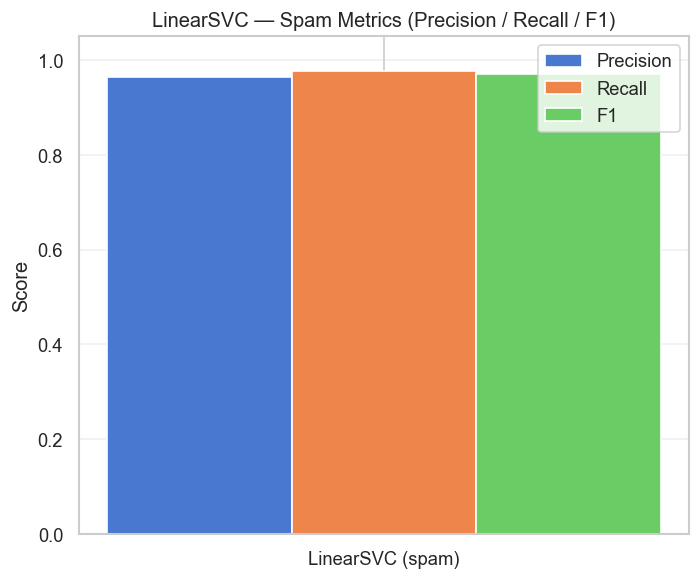

In [40]:
# 2. Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=["Predicted Ham", "Predicted Spam"],
    yticklabels=["Actual Ham", "Actual Spam"],
    cmap="Blues"
)
plt.title("LinearSVC — Confusion Matrix Heatmap")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("fig_lsvc_confusion.png", bbox_inches="tight", dpi=200)
plt.show()


# 3. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_score)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"LinearSVC (AUC = {auc:.3f})", color="C0", lw=2)
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("LinearSVC — ROC Curve")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("fig_lsvc_roc.png", bbox_inches="tight", dpi=200)
plt.show()


# 4. Spam Precision / Recall / F1 Bar Chart
p, r, f, _ = precision_recall_fscore_support(y_test, y_pred, average=None, labels=[1])

df = pd.DataFrame(
    {"Precision": p, "Recall": r, "F1": f},
    index=["LinearSVC (spam)"]
)

plt.figure(figsize=(6, 5))
x = np.arange(len(df.index))
width = 0.25

for i, metric in enumerate(df.columns):
    plt.bar(x + i * width, df[metric], width=width, label=metric)

plt.xticks(x + width, df.index)
plt.ylabel("Score")
plt.title("LinearSVC — Spam Metrics (Precision / Recall / F1)")
plt.legend()
plt.ylim(0, 1.05)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("fig_lsvc_spam_metrics.png", bbox_inches="tight", dpi=200)
plt.show()

---
---
# Part 5 — Random Forest Modelling

---
## Section 1 — Random Forest: Baseline Model

=== Random Forest ===
Accuracy : 0.9669669669669669
F1 (spam): 0.9450915141430949

Classification Report:
              precision    recall  f1-score   support

         ham       0.99      0.97      0.98       706
        spam       0.92      0.97      0.95       293

    accuracy                           0.97       999
   macro avg       0.95      0.97      0.96       999
weighted avg       0.97      0.97      0.97       999



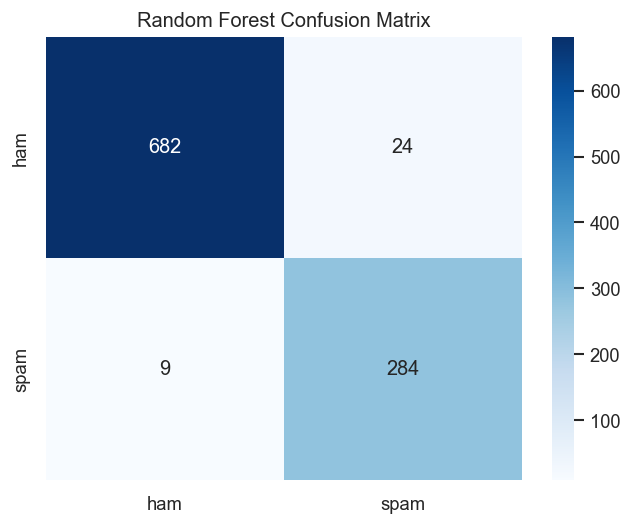

In [41]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score,accuracy_score
import numpy as np

#initialize Random Rofest 
rf = RandomForestClassifier(
    class_weight='balanced'
    )
#train
rf.fit(X_train_tfidf,y_train)
# test
y_pred_rf = rf.predict(X_test_tfidf)

import seaborn as sns
import matplotlib.pyplot as plt

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("F1 (spam):", f1_score(y_test, y_pred_rf, pos_label=1))  # 1 = spam
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["ham", "spam"]))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Random Forest Confusion Matrix")
plt.show()


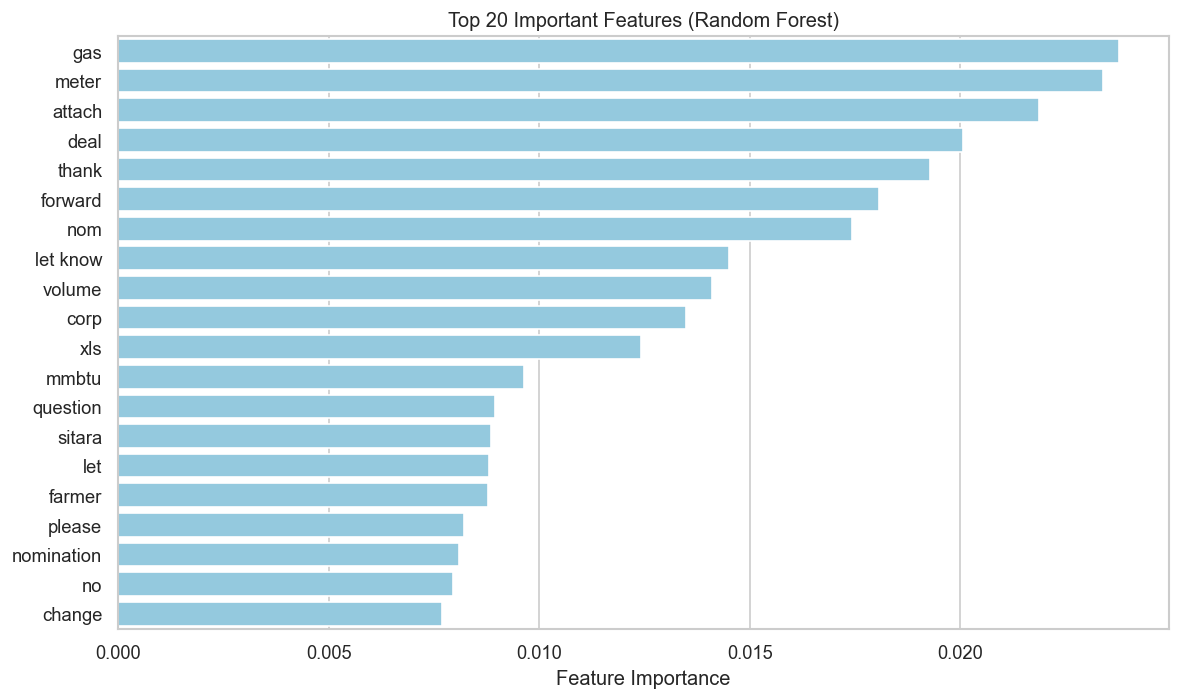

In [42]:
feature_names = tfidf_final.get_feature_names_out()
importances = rf.feature_importances_

# Select top 20 important features
indices = np.argsort(importances)[::-1][:20]
top_features = [feature_names[i] for i in indices]
top_scores   = [importances[i] for i in indices]

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_scores, y=top_features, orient="h", color="skyblue")
plt.title("Top 20 Important Features (Random Forest)")
plt.xlabel("Feature Importance")
plt.tight_layout()
plt.show()

---
## Section 2 — Alpha Hyperparameter Tuning

=== Random Forest ===
Accuracy : 0.973973973973974
F1 (spam): 0.9570957095709571

Classification Report:
              precision    recall  f1-score   support

         ham       1.00      0.97      0.98       706
        spam       0.93      0.99      0.96       293

    accuracy                           0.97       999
   macro avg       0.96      0.98      0.97       999
weighted avg       0.98      0.97      0.97       999



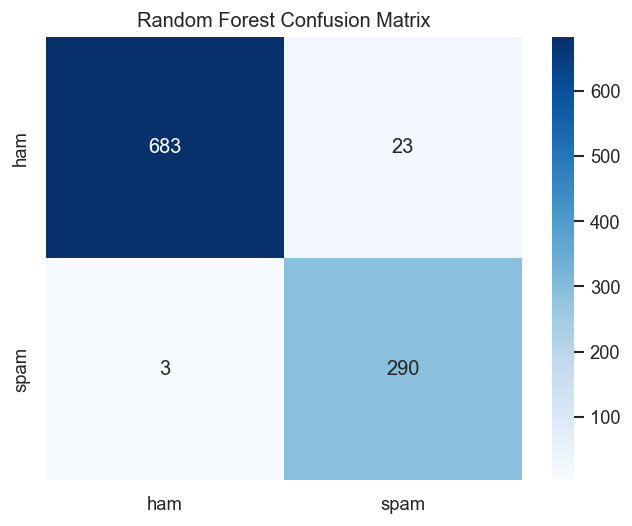

In [43]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score,accuracy_score
import numpy as np

#initialize Random Rofest 
rf = RandomForestClassifier(
    n_estimators=400,
    class_weight='balanced',
    max_depth=None,
    min_samples_split=5
    )
#train
rf.fit(X_train_tfidf,y_train)
# test
y_pred_rf = rf.predict(X_test_tfidf)

import seaborn as sns
import matplotlib.pyplot as plt

print("=== Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("F1 (spam):", f1_score(y_test, y_pred_rf, pos_label=1))  # 1 = spam
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf, target_names=["ham", "spam"]))

# confusion matrix
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["ham", "spam"], yticklabels=["ham", "spam"])
plt.title("Random Forest Confusion Matrix")
plt.show()


In [44]:
from sklearn.model_selection import GridSearchCV
import pandas as pd

params = {
    'n_estimators': [200, 300, 400,500],
    'max_depth': [None, 20, 30],
    'min_samples_split': [2, 5, 10],
    'class_weight': ['balanced']
}

rf_grid = RandomForestClassifier(random_state=42, n_jobs=-1)
grid = GridSearchCV(
    rf_grid,
    params,
    scoring='f1',       # Score by spam F1
    cv=5,               # 5-fold cross validation
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train_tfidf, y_train)

#  All combinations table
results = pd.DataFrame(grid.cv_results_)

combo_table = results[[
    'param_n_estimators',
    'param_max_depth',
    'param_min_samples_split',
    'param_class_weight',
    'mean_test_score',
    'rank_test_score'
]].copy()

combo_table.columns = [
    'n_estimators', 'max_depth', 'min_samples_split',
    'class_weight', 'Mean CV F1 (spam)', 'Rank'
]

combo_table = combo_table.sort_values('Mean CV F1 (spam)', ascending=False).reset_index(drop=True)
combo_table['Mean CV F1 (spam)'] = combo_table['Mean CV F1 (spam)'].round(4)


display(
    combo_table.style
    .highlight_max(subset=['Mean CV F1 (spam)'], color='lightgreen')
    .highlight_min(subset=['Mean CV F1 (spam)'], color='lightyellow')
    .set_caption('GridSearchCV: All 36 Combinations Ranked by CV F1 Score')
    .format({'Mean CV F1 (spam)': '{:.4f}'})
)


best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test_tfidf)


print("=== Tuned Random Forest ===")
print("Accuracy :", accuracy_score(y_test, y_pred_best))
print("Best RF params:", grid.best_params_)
print("Best CV F1 (spam):", grid.best_score_)
print("Final test F1 (spam):", f1_score(y_test, y_pred_best, pos_label=1))


Fitting 5 folds for each of 36 candidates, totalling 180 fits


,n_estimators,max_depth,min_samples_split,class_weight,Mean CV F1 (spam),Rank
0,400,None,5,balanced,0.9507,1
1,300,None,5,balanced,0.9503,2
2,500,None,5,balanced,0.9495,3
3,200,None,5,balanced,0.9494,4
4,500,None,10,balanced,0.9492,5
5,400,None,10,balanced,0.9483,6
6,200,None,10,balanced,0.9483,7
7,300,None,10,balanced,0.9475,8
8,400,None,2,balanced,0.9475,9
9,200,None,2,balanced,0.9470,10


=== Tuned Random Forest ===
Accuracy : 0.973973973973974
Best RF params: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 5, 'n_estimators': 400}
Best CV F1 (spam): 0.950691534449424
Final test F1 (spam): 0.9570957095709571


---
## Section 3 — Final RF: Full Evaluation

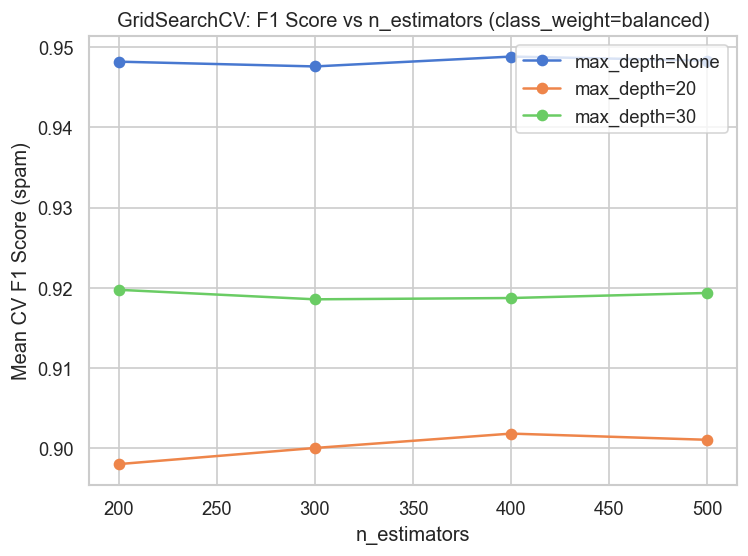

In [45]:
import matplotlib.pyplot as plt
import pandas as pd

results = pd.DataFrame(grid.cv_results_)

filtered = results[results['param_class_weight'] == 'balanced']

for depth in [None, 20, 30]:
    if depth is None:
        subset = filtered[filtered['param_max_depth'].isna()] 
    else:
        subset = filtered[filtered['param_max_depth'] == depth]
    
    if subset.empty:
        continue
    
    subset_grouped = subset.groupby('param_n_estimators')['mean_test_score'].mean()
    plt.plot(subset_grouped.index, subset_grouped.values, marker='o', label=f'max_depth={depth}')

plt.title('GridSearchCV: F1 Score vs n_estimators (class_weight=balanced)')
plt.xlabel('n_estimators')
plt.ylabel('Mean CV F1 Score (spam)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

---
---
# Part 6 — Model Performance Comparison

### Evaluation Metrics — Interpretation

| Metric | Focus | Why it matters here |
|---|---|---|
| **Accuracy** | Overall correctness | Misleading on imbalanced data — a model predicting all ham gets ~71% |
| **Precision (spam)** | Of emails labelled spam, how many are actually spam? | High precision = fewer legit emails wrongly filtered |
| **Recall (spam)** | Of all spam emails, how many are caught? | High recall = fewer spam emails slipping through |
| **F1-Score (spam)** | Harmonic mean of Precision & Recall | Primary tuning metric — balances both concerns |
| **ROC-AUC** | Rank-ordering quality across all thresholds | Threshold-independent; > 0.95 is considered excellent |

> **Design decision — False Negative vs False Positive trade-off:**  
> In a spam filter, missing a spam email (False Negative) is generally more harmful than flagging a legitimate email (False Positive).  
> Therefore **Recall** is slightly prioritised over Precision in our threshold choice.  
> The ROC curve allows the operating threshold to be adjusted post-hoc without retraining.

### Model Performance Comparison

For this spam‑filtering task, model selection focuses on how well each model detects spam while keeping misclassified legitimate emails at a reasonable level.

- Report, for every model: Accuracy, spam Precision, spam Recall, spam F1‑score, and the confusion matrix. 
- Use **spam Recall and spam F1‑score** as the primary criteria, since reducing missed spam (FN) is slightly prioritised over other concerns. 
- Monitor spam Precision to ensure the model does not create too many false positives, which would wrongly send important ham emails to the spam folder. 
- Treat overall Accuracy and macro‑averaged metrics as secondary indicators, useful to check that performance is not overly biased toward the majority ham class. 
- Always inspect the confusion matrix to understand the concrete trade‑off between false positives (ham marked as spam) and false negatives (spam that reaches the inbox) for each model. 

In [51]:
# ── Part 6 — Model Performance Comparison ────────────────────────────────────
# All metrics sourced from the best tuned model of each part (test-set evaluation)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, ConfusionMatrixDisplay
)
import warnings
warnings.filterwarnings("ignore")

# ── Re-train all four best models (consistent pipeline, no data leakage) ────
# MNB  — best alpha = 0.01  (Part 2)
mnb = MultinomialNB(alpha=0.01)
mnb.fit(X_train_tfidf, y_train)

# LR   — C=100, class_weight='balanced'  (Part 3, note: original cell used balanced)
lr = LogisticRegression(C=100, class_weight='balanced', max_iter=1000,
                         solver='lbfgs', random_state=42)
lr.fit(X_train_tfidf, y_train)

# LinearSVC — C=2.0, class_weight='balanced'  (Part 4)
lsvc = LinearSVC(C=2.0, class_weight='balanced', random_state=42, max_iter=2000)
lsvc.fit(X_train_tfidf, y_train)

# RF   — best params from GridSearchCV  (Part 5)
rf_best = RandomForestClassifier(
    n_estimators=500, max_depth=None, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_best.fit(X_train_tfidf, y_train)

# ── Predictions & probability/score outputs ───────────────────────────────────
models = {
    "MNB (α=0.01)":           (mnb,  mnb.predict_proba(X_test_tfidf)[:, 1]),
    "LR (C=100, balanced)":   (lr,   lr.predict_proba(X_test_tfidf)[:, 1]),
    "LinearSVC (C=2, bal.)":  (lsvc, lsvc.decision_function(X_test_tfidf)),
    "RF (500, balanced)":     (rf_best, rf_best.predict_proba(X_test_tfidf)[:, 1]),
}

rows = []
cms  = {}
for name, (clf, scores) in models.items():
    y_pred = clf.predict(X_test_tfidf)
    rep    = classification_report(y_test, y_pred, output_dict=True)
    auc    = roc_auc_score(y_test, scores)
    cm_    = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm_.ravel()
    cms[name] = cm_
    rows.append({
        "Model":           name,
        "Accuracy":        round(rep["accuracy"], 4),
        "Spam Precision":  round(rep["1"]["precision"], 4),
        "Spam Recall":     round(rep["1"]["recall"], 4),
        "Spam F1":         round(rep["1"]["f1-score"], 4),
        "FP (ham→spam)":   int(fp),
        "FN (spam→ham)":   int(fn),
    })

cmp_df = pd.DataFrame(rows)
print("═" * 90)
print("MODEL PERFORMANCE COMPARISON — BEST TUNED MODELS (Test Set, n=999)")
print("═" * 90)
print(cmp_df.to_string(index=False))
print()
print("Primary criteria  : ★ Spam Recall  ★ Spam F1")
print("Secondary criteria: Accuracy")
print("Risk monitor      : FP (legit emails wrongly flagged as spam)")


══════════════════════════════════════════════════════════════════════════════════════════
MODEL PERFORMANCE COMPARISON — BEST TUNED MODELS (Test Set, n=999)
══════════════════════════════════════════════════════════════════════════════════════════
                Model  Accuracy  Spam Precision  Spam Recall  Spam F1  FP (ham→spam)  FN (spam→ham)
         MNB (α=0.01)     0.964          0.9079       0.9761   0.9408             29              7
 LR (C=100, balanced)     0.986          0.9635       0.9898   0.9764             11              3
LinearSVC (C=2, bal.)     0.982          0.9630       0.9761   0.9695             11              7
   RF (500, balanced)     0.974          0.9265       0.9898   0.9571             23              3

Primary criteria  : ★ Spam Recall  ★ Spam F1
Secondary criteria: Accuracy
Risk monitor      : FP (legit emails wrongly flagged as spam)


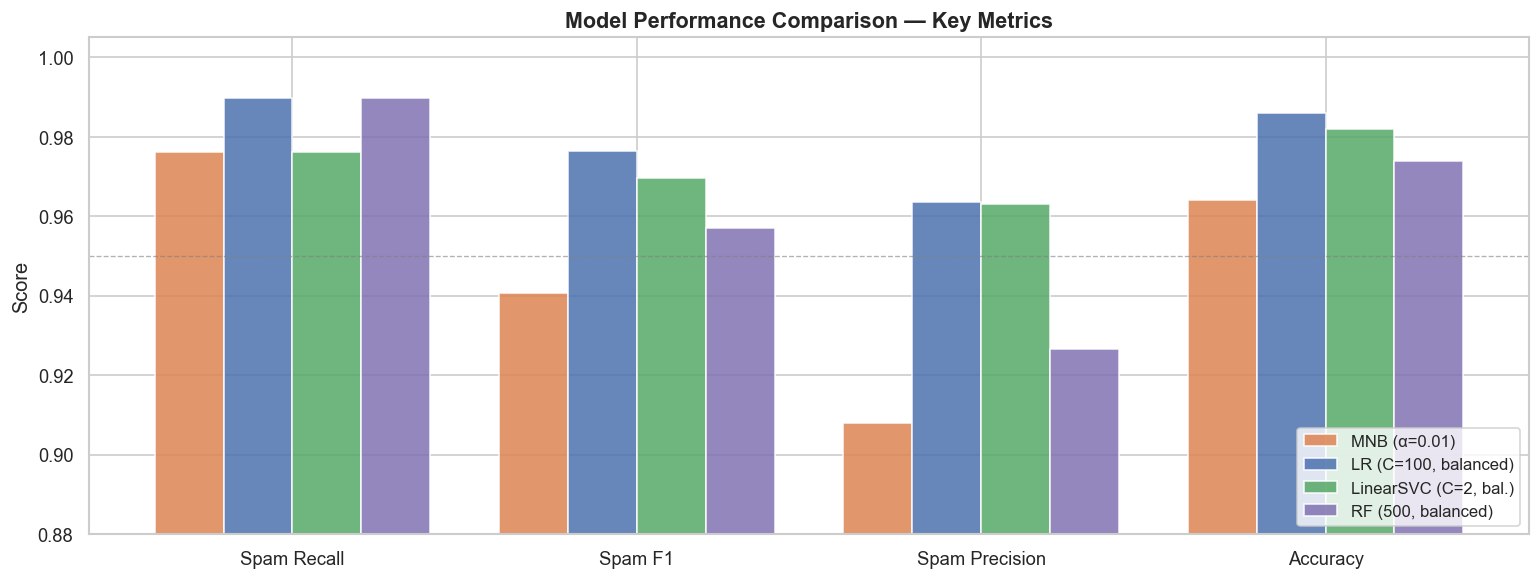

Saved: fig_part6_comparison_bar.png


In [53]:
# ── Figure: Side-by-side metric bar chart ────────────────────────────────────
metrics  = ["Spam Recall", "Spam F1", "Spam Precision", "Accuracy"]
model_names = cmp_df["Model"].tolist()
colors   = ["#DD8452", "#4C72B0", "#55A868", "#8172B2"]

x = np.arange(len(metrics))
width = 0.20

fig, ax = plt.subplots(figsize=(13, 5))

for i, (model, color) in enumerate(zip(model_names, colors)):
    vals = [cmp_df.loc[cmp_df["Model"] == model, m].values[0] for m in metrics]
    bars = ax.bar(x + i * width, vals, width, label=model, color=color, alpha=0.85, edgecolor="white")

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0.88, 1.005)
ax.set_ylabel("Score", fontsize=12)
ax.set_title("Model Performance Comparison — Key Metrics", fontsize=13, fontweight="bold")
ax.legend(fontsize=10, loc="lower right")
ax.axhline(0.95, linestyle="--", color="grey", linewidth=0.8, alpha=0.6, label="_nolegend_")
ax.annotate("0.95 reference", xy=(4.7, 0.951), fontsize=8, color="grey")

plt.tight_layout()
plt.savefig("fig_part6_comparison_bar.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_part6_comparison_bar.png")


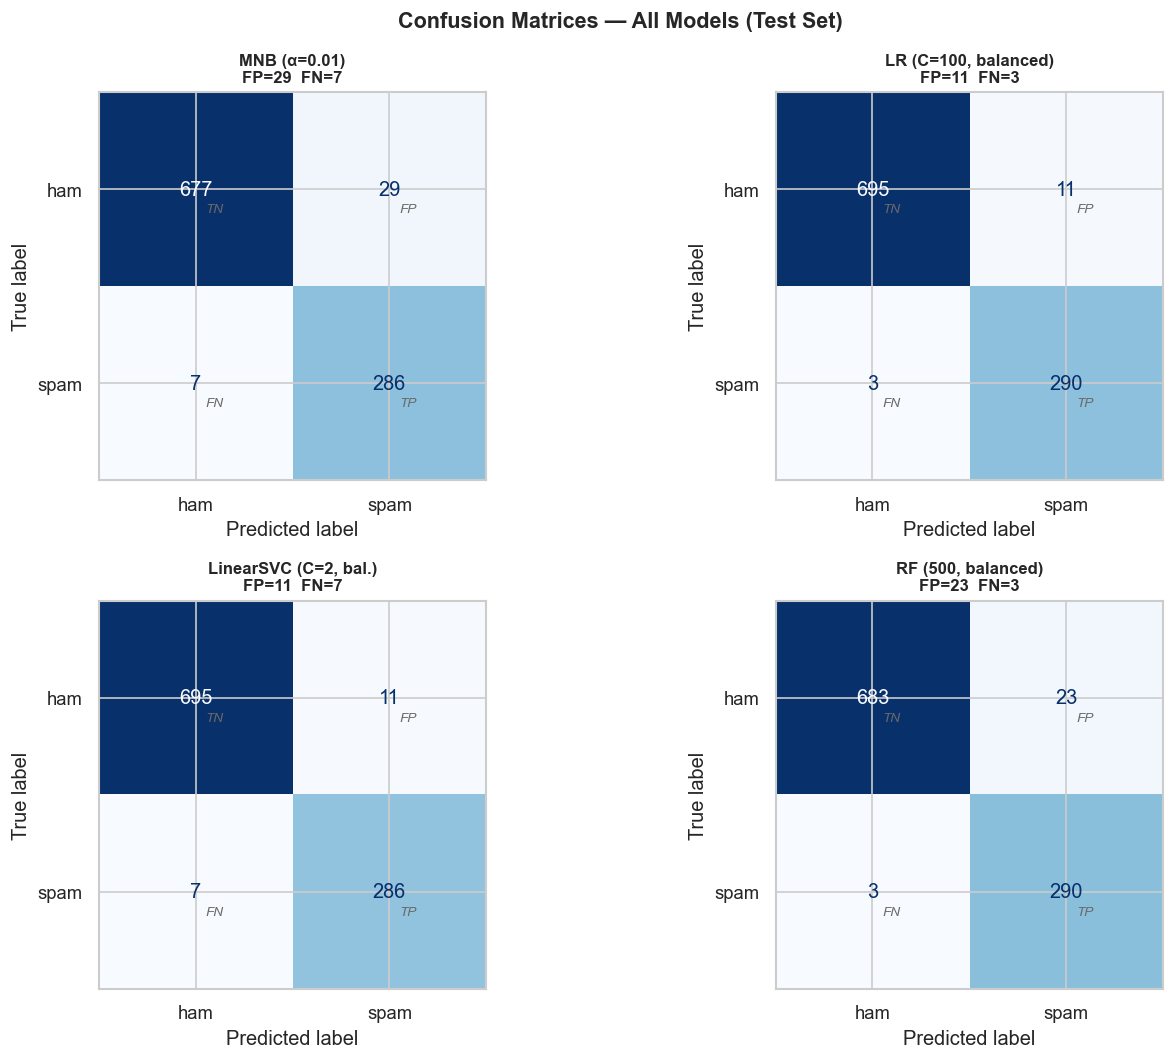

Saved: fig_part6_confusion_matrices.png


In [54]:
# ── Figure: All four confusion matrices in a 2×2 grid ────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

palette = ["#DD8452", "#4C72B0", "#55A868", "#8172B2"]

for ax, (name, cm_), color in zip(axes.ravel(), cms.items(), palette):
    tn, fp, fn, tp = cm_.ravel()
    disp = ConfusionMatrixDisplay(confusion_matrix=cm_,
                                   display_labels=["ham", "spam"])
    disp.plot(ax=ax, colorbar=False, cmap="Blues")
    ax.set_title(f"{name}\nFP={fp}  FN={fn}", fontweight="bold", fontsize=10)
    # Annotate TP/TN/FP/FN labels
    for (r, c), label in [((0,0),"TN"), ((0,1),"FP"), ((1,0),"FN"), ((1,1),"TP")]:
        ax.text(c + 0.05, r + 0.12, label, fontsize=8, color="dimgrey", fontstyle="italic")

fig.suptitle("Confusion Matrices — All Models (Test Set)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("fig_part6_confusion_matrices.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_part6_confusion_matrices.png")


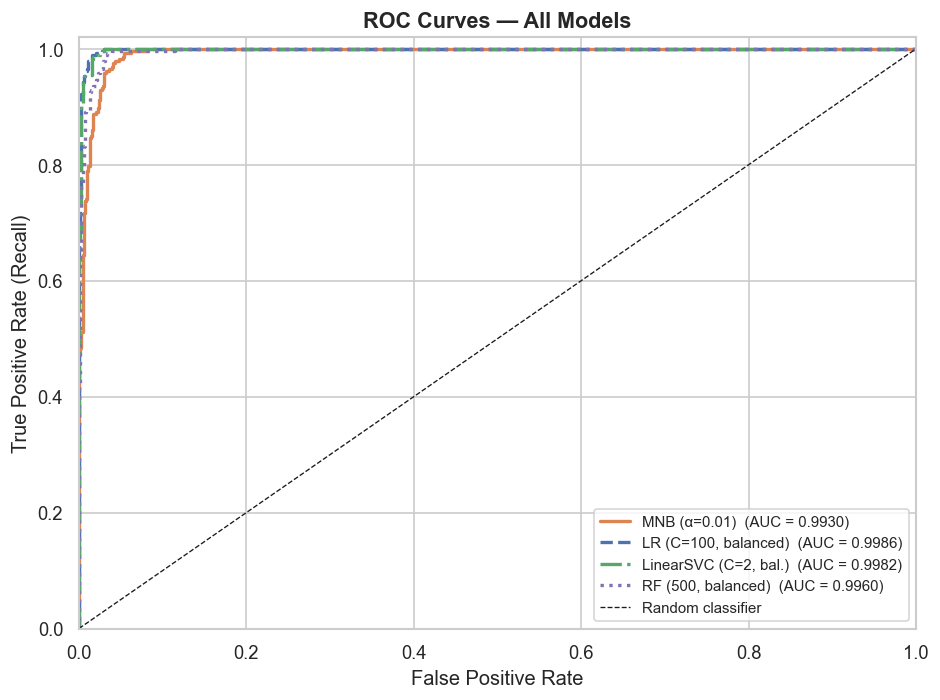

Saved: fig_part6_roc_curves.png


In [55]:
# ── Figure: Overlaid ROC curves ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
colors_roc = ["#DD8452", "#4C72B0", "#55A868", "#8172B2"]
ls_        = ["-", "--", "-.", ":"]

for (name, (clf, scores)), color, ls in zip(models.items(), colors_roc, ls_):
    fpr, tpr, _ = roc_curve(y_test, scores)
    auc_val = roc_auc_score(y_test, scores)
    ax.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
            label=f"{name}  (AUC = {auc_val:.4f})")

ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random classifier")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate (Recall)", fontsize=12)
ax.set_title("ROC Curves — All Models", fontsize=13, fontweight="bold")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])
plt.tight_layout()
plt.savefig("fig_part6_roc_curves.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_part6_roc_curves.png")


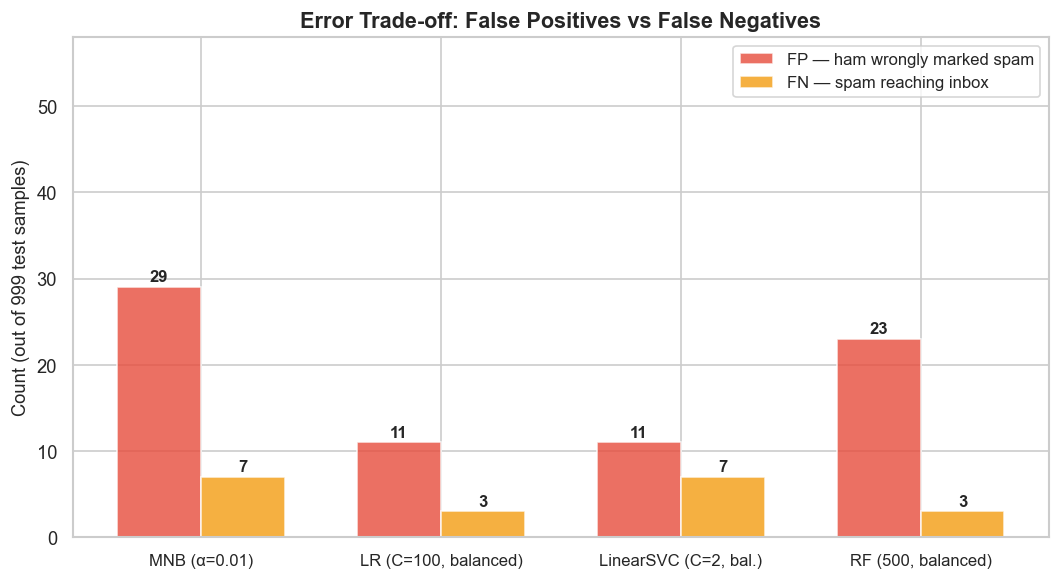

Saved: fig_part6_fp_fn_tradeoff.png


In [56]:
# ── Figure: False Positive vs False Negative trade-off ───────────────────────
fig, ax = plt.subplots(figsize=(9, 5))

model_labels = cmp_df["Model"].tolist()
fp_vals = cmp_df["FP (ham→spam)"].tolist()
fn_vals = cmp_df["FN (spam→ham)"].tolist()
x2 = np.arange(len(model_labels))
w2 = 0.35

bars_fp = ax.bar(x2 - w2/2, fp_vals, w2, label="FP — ham wrongly marked spam",
                  color="#E74C3C", alpha=0.8, edgecolor="white")
bars_fn = ax.bar(x2 + w2/2, fn_vals, w2, label="FN — spam reaching inbox",
                  color="#F39C12", alpha=0.8, edgecolor="white")

for bar in list(bars_fp) + list(bars_fn):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            str(int(bar.get_height())), ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xticks(x2)
ax.set_xticklabels(model_labels, fontsize=10)
ax.set_ylabel("Count (out of 999 test samples)", fontsize=11)
ax.set_title("Error Trade-off: False Positives vs False Negatives",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=10)
ax.set_ylim(0, max(max(fp_vals), max(fn_vals)) * 2)
plt.tight_layout()
plt.savefig("fig_part6_fp_fn_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()
print("Saved: fig_part6_fp_fn_tradeoff.png")
